# OC Project: Project 5
**Author:** Ricardo Vega  
**Creation Date:** 2025-07-18  
**Purpose**: Applying PCA first to Manuel's M67 file to see if I can learn a little more about PCA and how to apply it. Once that is done, we may apply it just to `cluster_flag` == 1 stars and the HR2 catalogue for different clusters.

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# PCA libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# New imports for calculation functions and all current MC cluster files with the calculations already done
%run /home/jail/dlusers/ricardo_vega/Silva_OC_Project/Universal_Functions.ipynb
%run /home/jail/dlusers/ricardo_vega/Silva_OC_Project/MC_General/MC_Data_Imports/MC_Data_Imports.ipynb

/data0/sw/anaconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/data0/sw/anaconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/data0/sw/anaconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/data0/sw/anaconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/data0/sw/anaconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/data0/sw/anaconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:396: Runtim

# M67

## 3 Components

### Define Data

In [2]:
# Setting up the data we will actually use for PCA (using entire dataset):
pca_data_mc_m67 = mc_m67[['vra', 'vdec', 'r_med_geo']].copy()
pca_data_mc_m67

,vra,vdec,r_med_geo
1,-27.507460,68.208368,1299.076538
2,-25.254761,7.127286,259.710754
3,-29.412146,-4.910378,538.822510
4,-43.034580,-75.968074,1644.195190
5,-11.713372,20.052976,844.427246
...,...,...,...
115521,-46.562558,-25.575187,1680.500244
115522,36.645438,-131.039794,2229.045654
115523,16.404410,-43.896490,2228.217285
115524,-14.381212,10.725368,1570.699341


### Applying PCA

In [3]:
sigma = 3
pca_data_mc_m67 = pca_data_mc_m67
n_components = 3
apply_pca(sigma, pca_data_mc_m67, n_components)

Shape before trimming: (85861, 3)
Shape after trimming: (82432, 3)
We have effectively removed 3429 stars to ease computation. 

Column 0: Mean = 0.00, Variance = 1.00
Column 1: Mean = 0.00, Variance = 1.00
Column 2: Mean = 0.00, Variance = 1.00
Marix Mean = 0.00, Matrix Variance = 1.00 

Number of principal components: 3 

Explained variance ratio: [0.41013009 0.3531315  0.23673842] 

Original dataset:


,vra,vdec,r_med_geo
1,-27.507460,68.208368,1299.076538
2,-25.254761,7.127286,259.710754
3,-29.412146,-4.910378,538.822510
4,-43.034580,-75.968074,1644.195190
5,-11.713372,20.052976,844.427246
...,...,...,...
115521,-46.562558,-25.575187,1680.500244
115522,36.645438,-131.039794,2229.045654
115523,16.404410,-43.896490,2228.217285
115524,-14.381212,10.725368,1570.699341



Trimmed and scaled dataset:


,vra,vdec,r_med_geo
0,-0.274149,2.651412,-0.206556
1,-0.204367,0.913569,-1.414478
2,-0.333150,0.571081,-1.090102
3,-0.755129,-1.450611,0.194531
4,0.215102,1.281323,-0.734937
...,...,...,...
82427,-0.864415,-0.016862,0.236724
82428,1.713103,-3.017479,0.874228
82429,1.086101,-0.538129,0.873265
82430,0.132461,1.015940,0.109116



PC dataframe:


,PC1,PC2,PC3
0,-2.205852,0.022201,-1.510474
1,-1.429296,-0.881215,0.240195
2,-1.086961,-0.555982,0.367211
3,0.807821,0.675844,1.266094
4,-1.189772,-0.687370,-0.583228
...,...,...,...
82427,-0.295609,0.771340,0.348117
82428,3.479190,-0.540286,0.638361
82429,1.325941,-0.123678,-0.677034
82430,-0.644330,-0.021368,-0.803721



PCA transformation coefficients matrix:


,vra,vdec,r_med_geo
PC1,0.482169,-0.746360,0.458760
PC2,-0.695389,-0.007547,0.718594
PC3,-0.532868,-0.665500,-0.522649


### Plotting Trimmed/Scaled Data and PCs

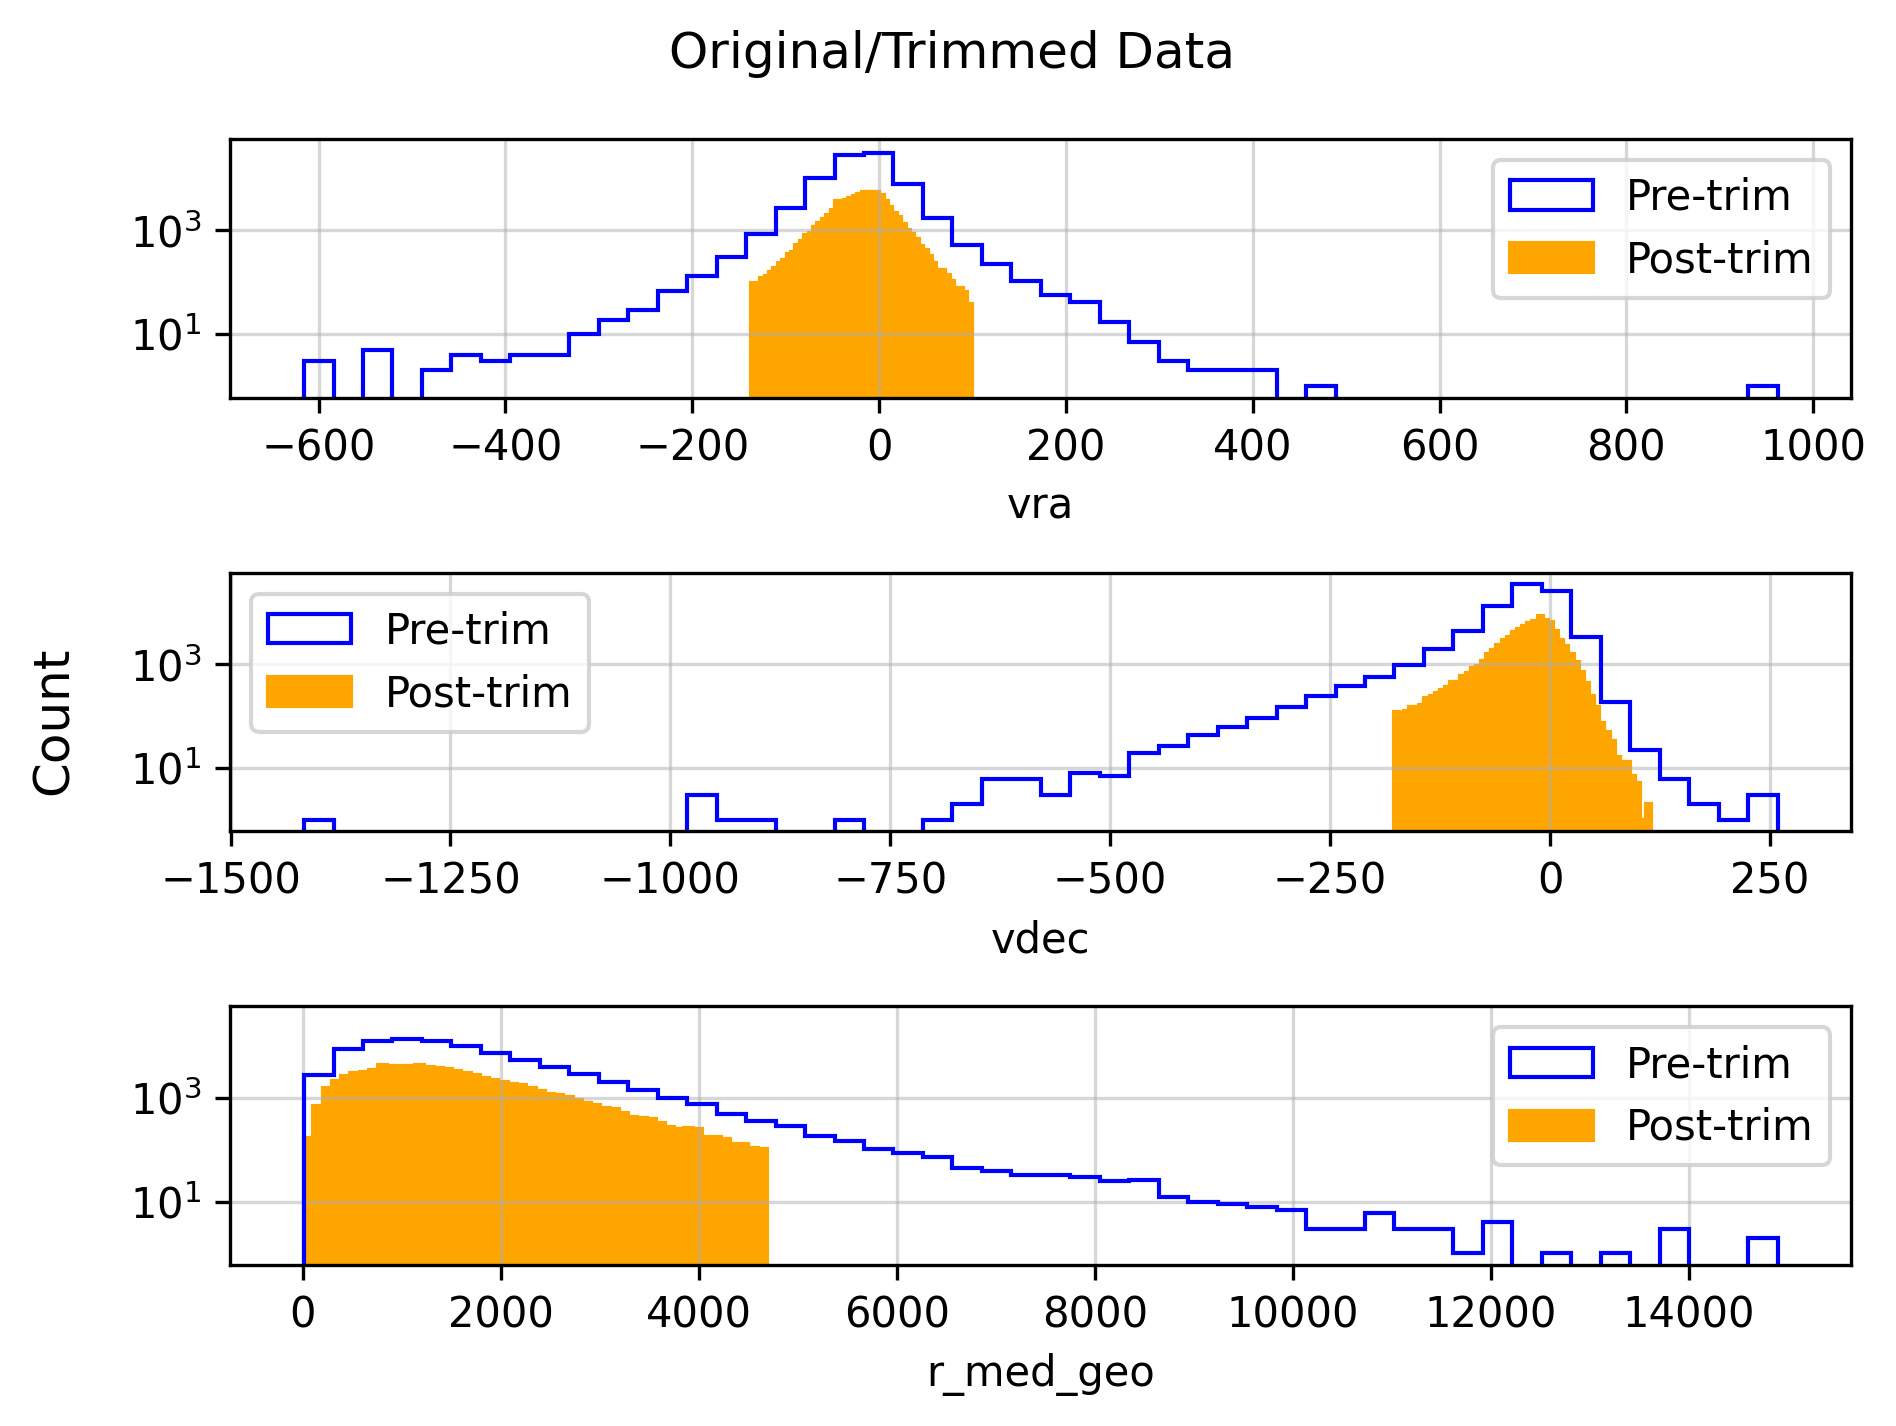

In [4]:
# In the cell below this, you can always plot particular parameters against each other
## e.g., vdec vs. vra, as done in the original example
# Visualizing how much data has been trimmed from the z-score method

trimmed_data_plot(pca_data_mc_m67, pca_data_trimmed_zscore, 50)

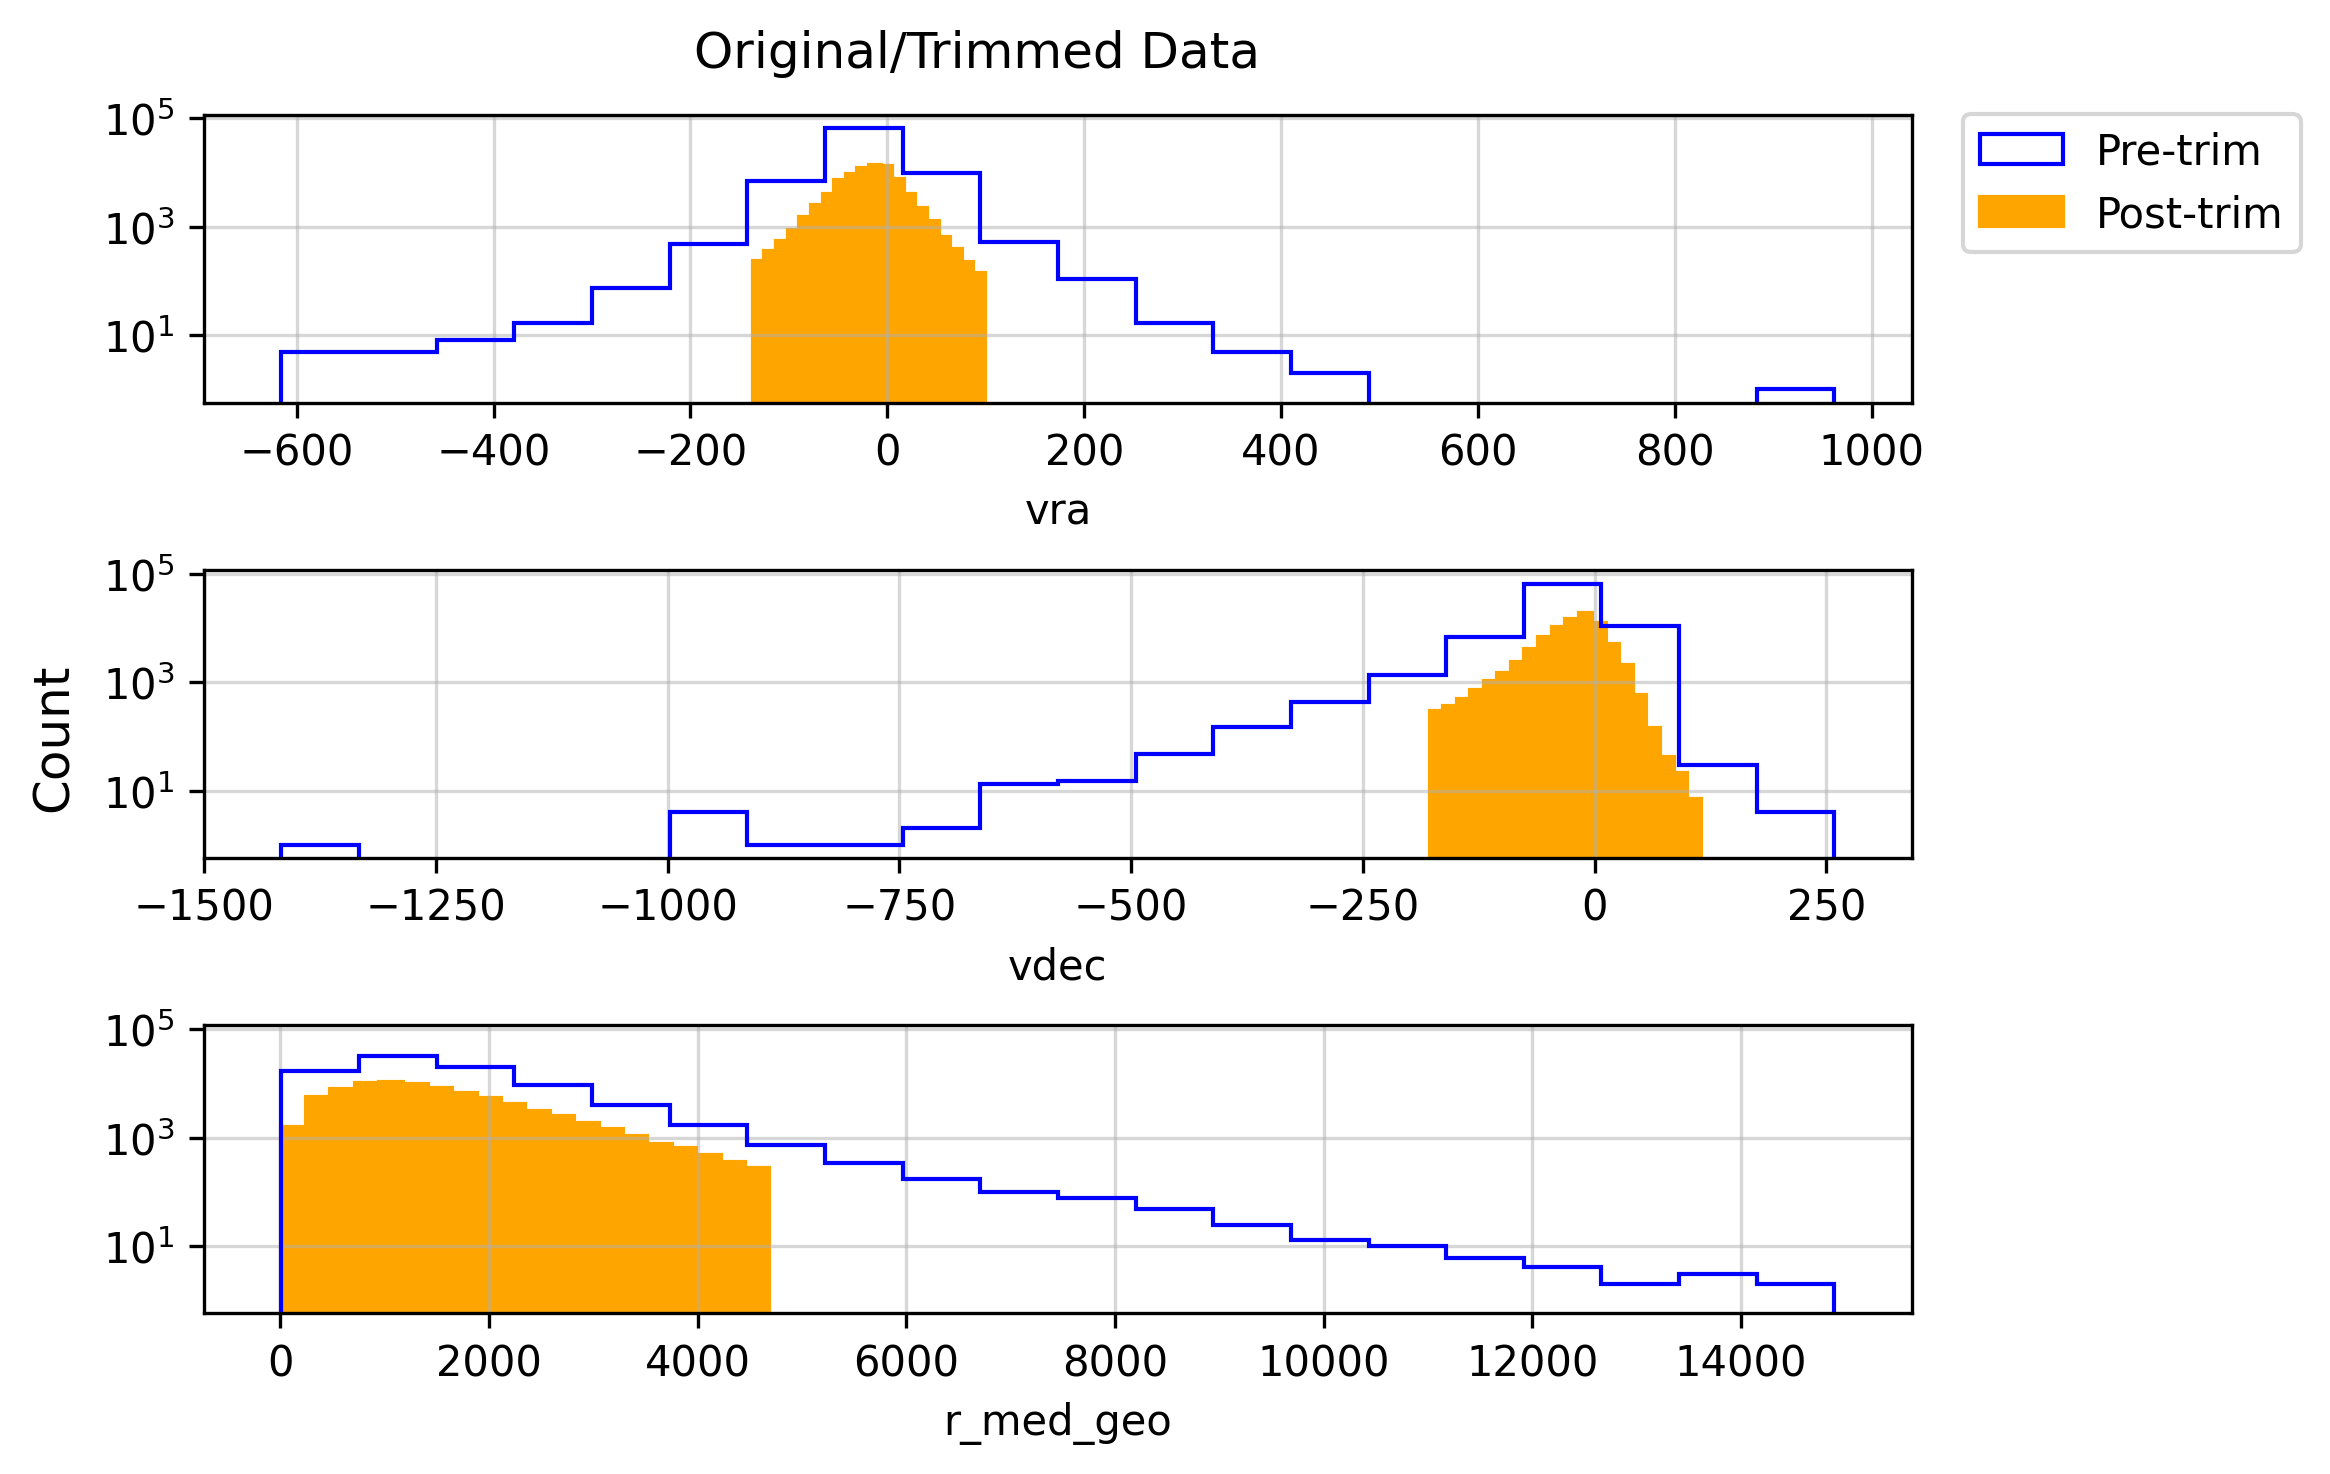

In [5]:
# Generalized using axes environement

fig, axs = plt.subplots(len(pca_data_mc_m67.columns), 1, sharey=True, constrained_layout=True, dpi=300)
fig.suptitle('Original/Trimmed Data')
fig.supylabel('Count')

column_list = pca_data_mc_m67.columns
length_array = np.arange(len(pca_data_mc_m67.columns))

for i, col in zip(length_array, column_list):
    ax = axs[i]
    ax.hist(pca_data_mc_m67[col], bins=20, log=True, histtype='step', ec='b', fc='b')
    ax.hist(pca_data_trimmed_zscore[col], bins=20, log=True, ec='orange', fc='orange')
    ax.set_xlabel(pca_data_mc_m67[col].name)
    ax.set_aspect('auto')
    ax.grid(alpha=0.5)
    #ax.legend()

fig.legend(['Pre-trim', 'Post-trim'], bbox_to_anchor=(1.2, 0.9468))

plt.show()
plt.close()

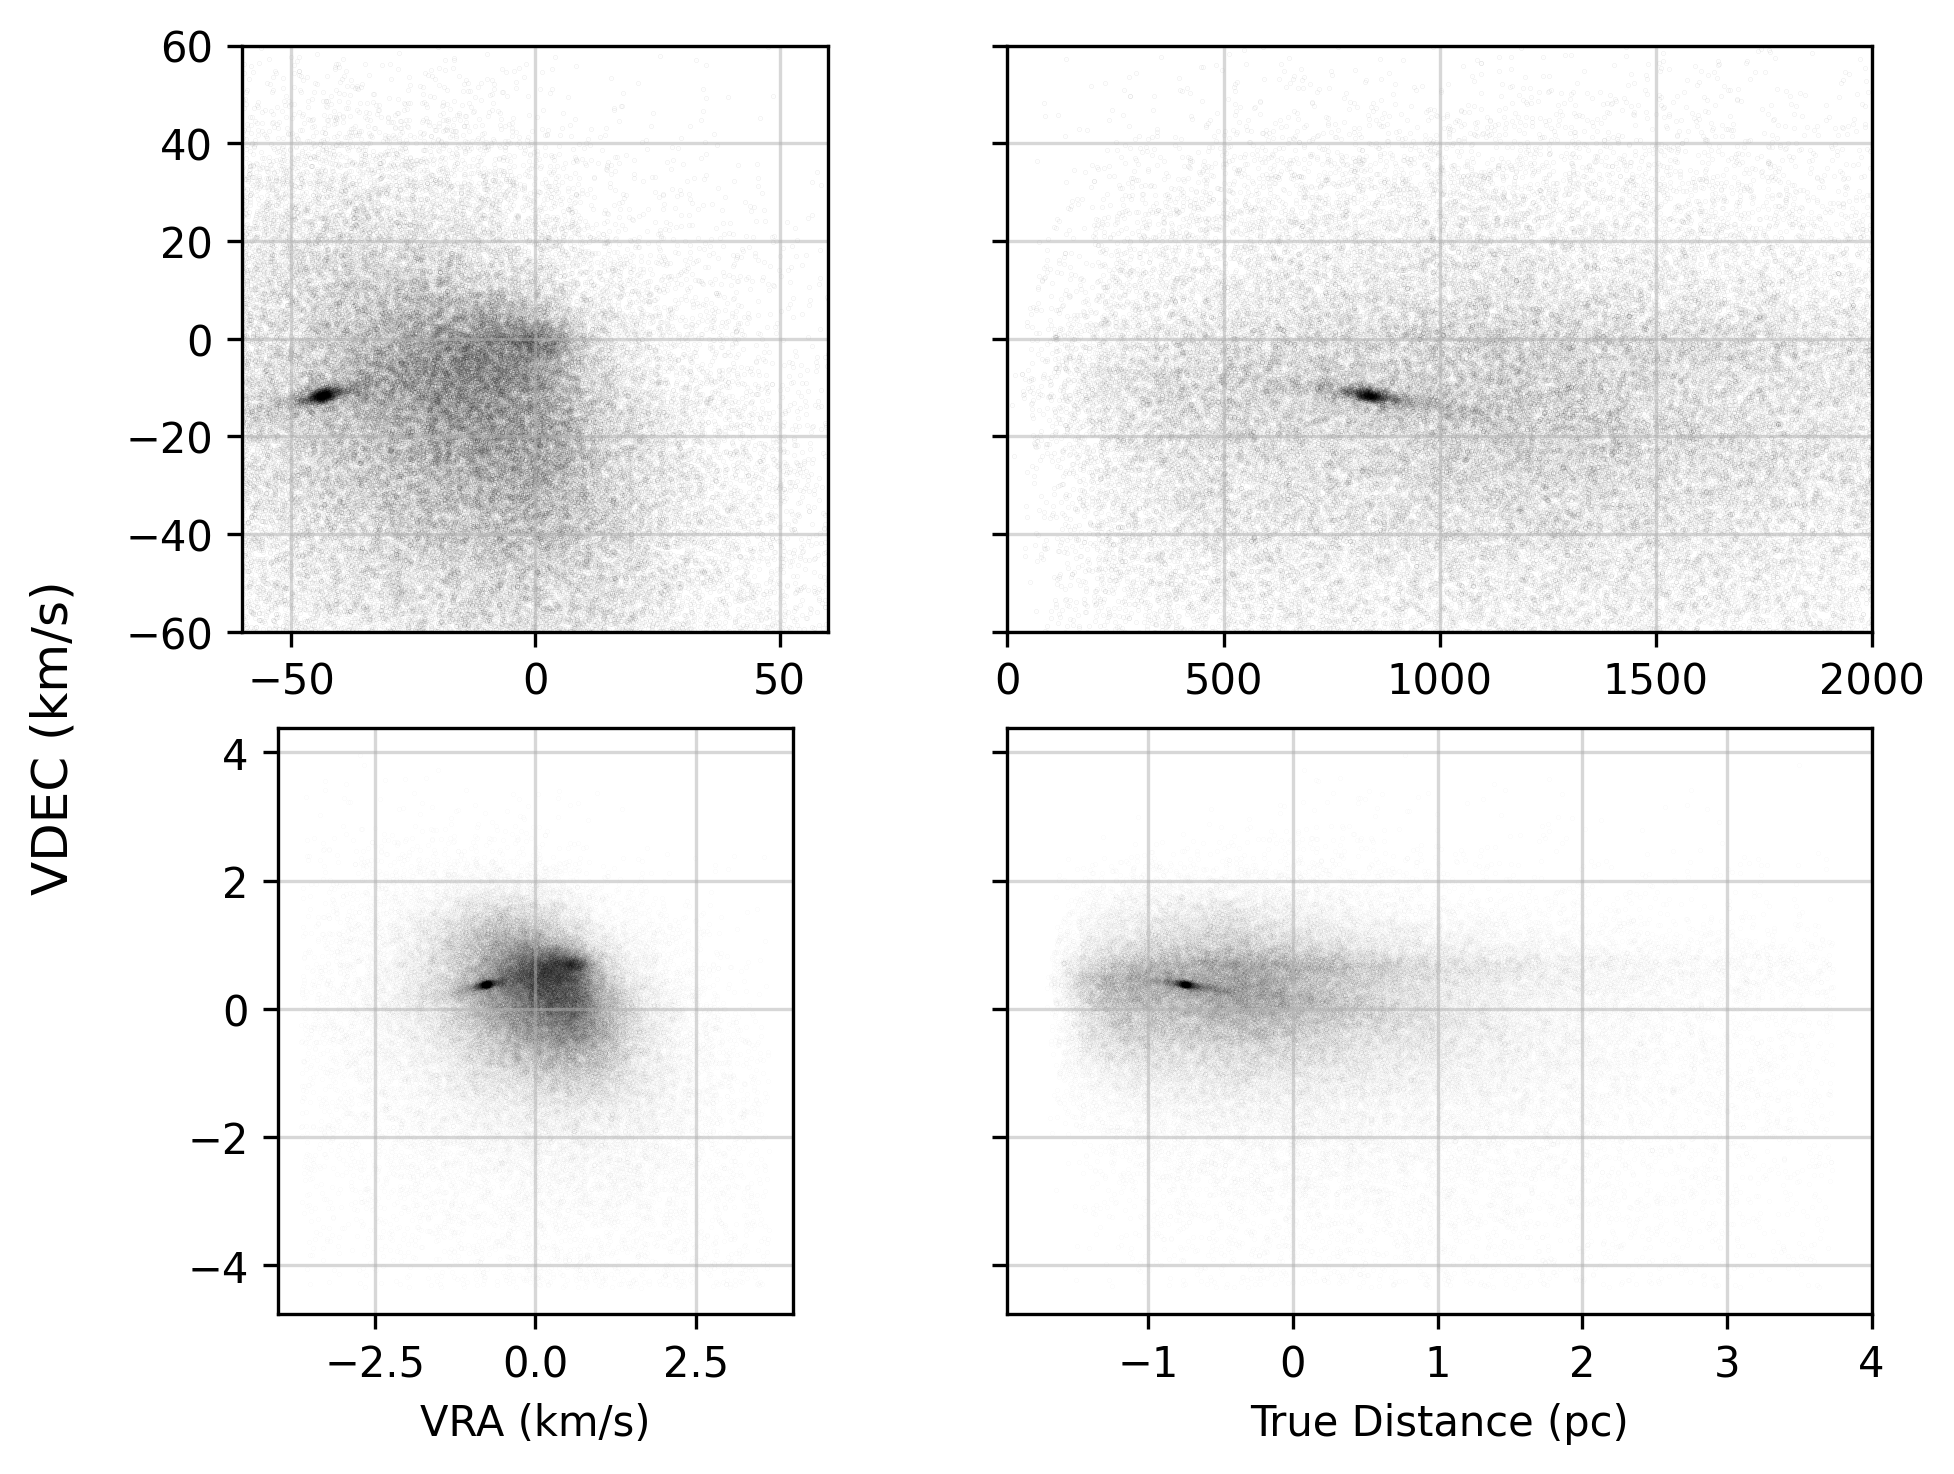

In [6]:
# Orignial vs. Trimmed Data

vra = pca_data_mc_m67.vra
vdec = pca_data_mc_m67.vdec
distance = pca_data_mc_m67.r_med_geo

vra_ts = pca_data_scaled_df.vra
vdec_ts = pca_data_scaled_df.vdec
distance_ts = pca_data_scaled_df.r_med_geo

fig, axs = plt.subplots(2, 2, sharey='row', constrained_layout=True, dpi=300)
fig.supylabel('VDEC (km/s)')

# VDEC vs. VRA
ax = axs[0,0]
ax.scatter(vra, vdec, s=0.01, alpha=0.1, c='0')
ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
ax.set_aspect(1)
ax.grid(alpha=0.5)

# VDEC vs. Distance
ax = axs[0,1]
ax.scatter(distance, vdec, s=0.01, alpha=0.1, c='0')
ax.set_xlim(0, 2000)
ax.set_aspect('auto')
ax.grid(alpha=0.5)

ax = axs[1,0]
ax.scatter(vra_ts, vdec_ts, s=0.001, alpha=0.1, c='0')
ax.set_xlabel('VRA (km/s)')
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[1,1]
ax.scatter(distance_ts, vdec_ts, s=0.001, alpha=0.1, c='0')
ax.set_xlabel('True Distance (pc)')
ax.set_aspect('auto')
ax.grid(alpha=0.5)

plt.show()
plt.close()

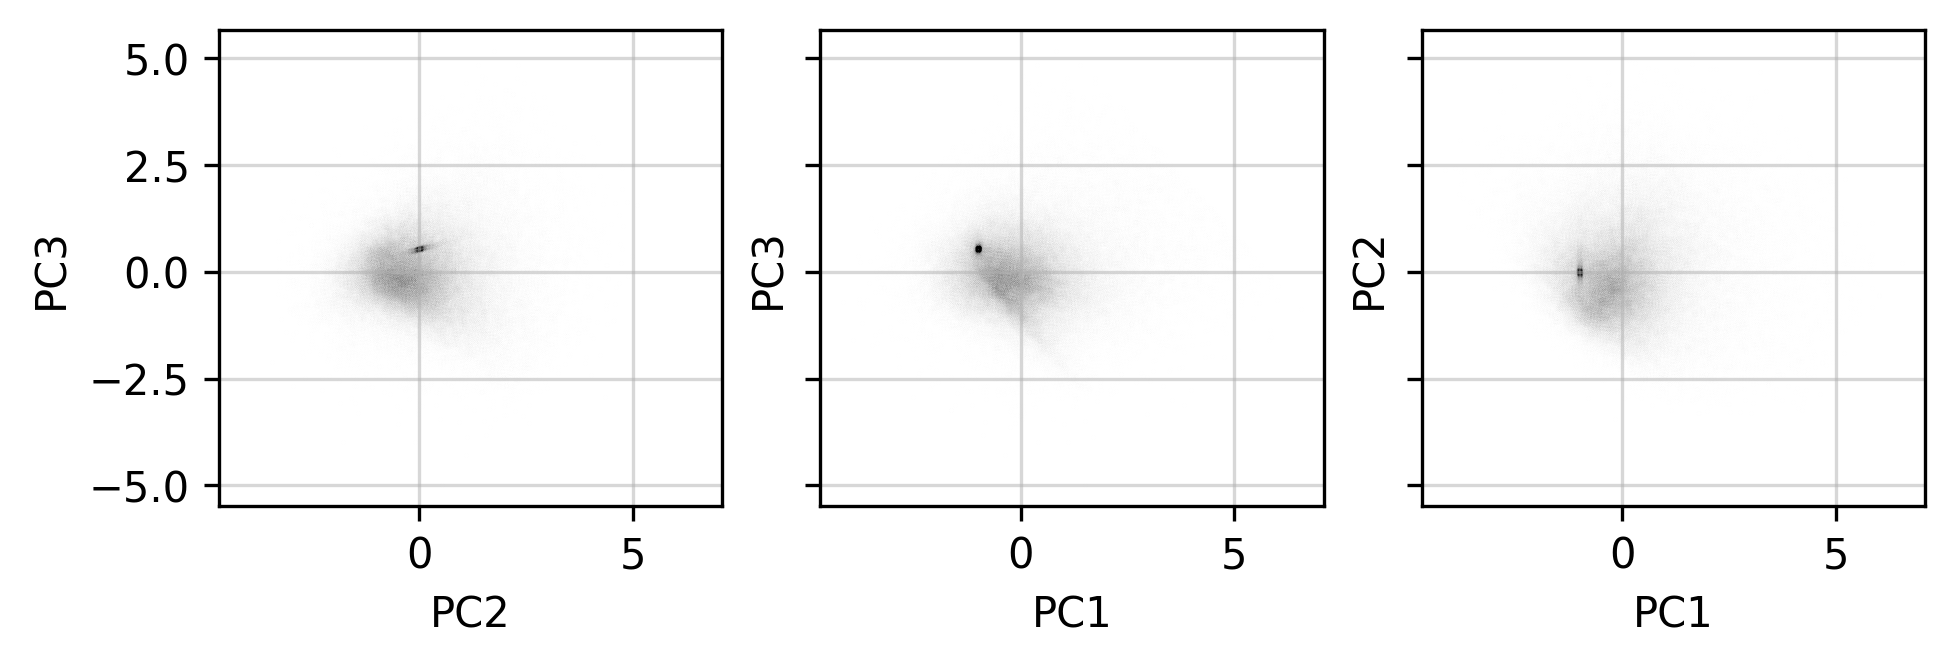

In [7]:
# PC vs. PC

pc1 = pc_df.PC1
pc2 = pc_df.PC2
pc3 = pc_df.PC3

fig, axs = plt.subplots(1, 3, sharey=True, sharex=True, constrained_layout=True, dpi=300)

ax = axs[0]
ax.scatter(pc2, pc3, s=0.00001, alpha=0.3, c='0')
ax.set_xlabel('PC2')
ax.set_ylabel('PC3')
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[1]
ax.scatter(pc1, pc3, s=0.00001, alpha=0.3, c='0')
ax.set_xlabel('PC1')
ax.set_ylabel('PC3')
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[2]
ax.scatter(pc1, pc2, s=0.00001, alpha=0.3, c='0')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_aspect(1)
ax.grid(alpha=0.5)

plt.show()
plt.close()

### Scree Plot

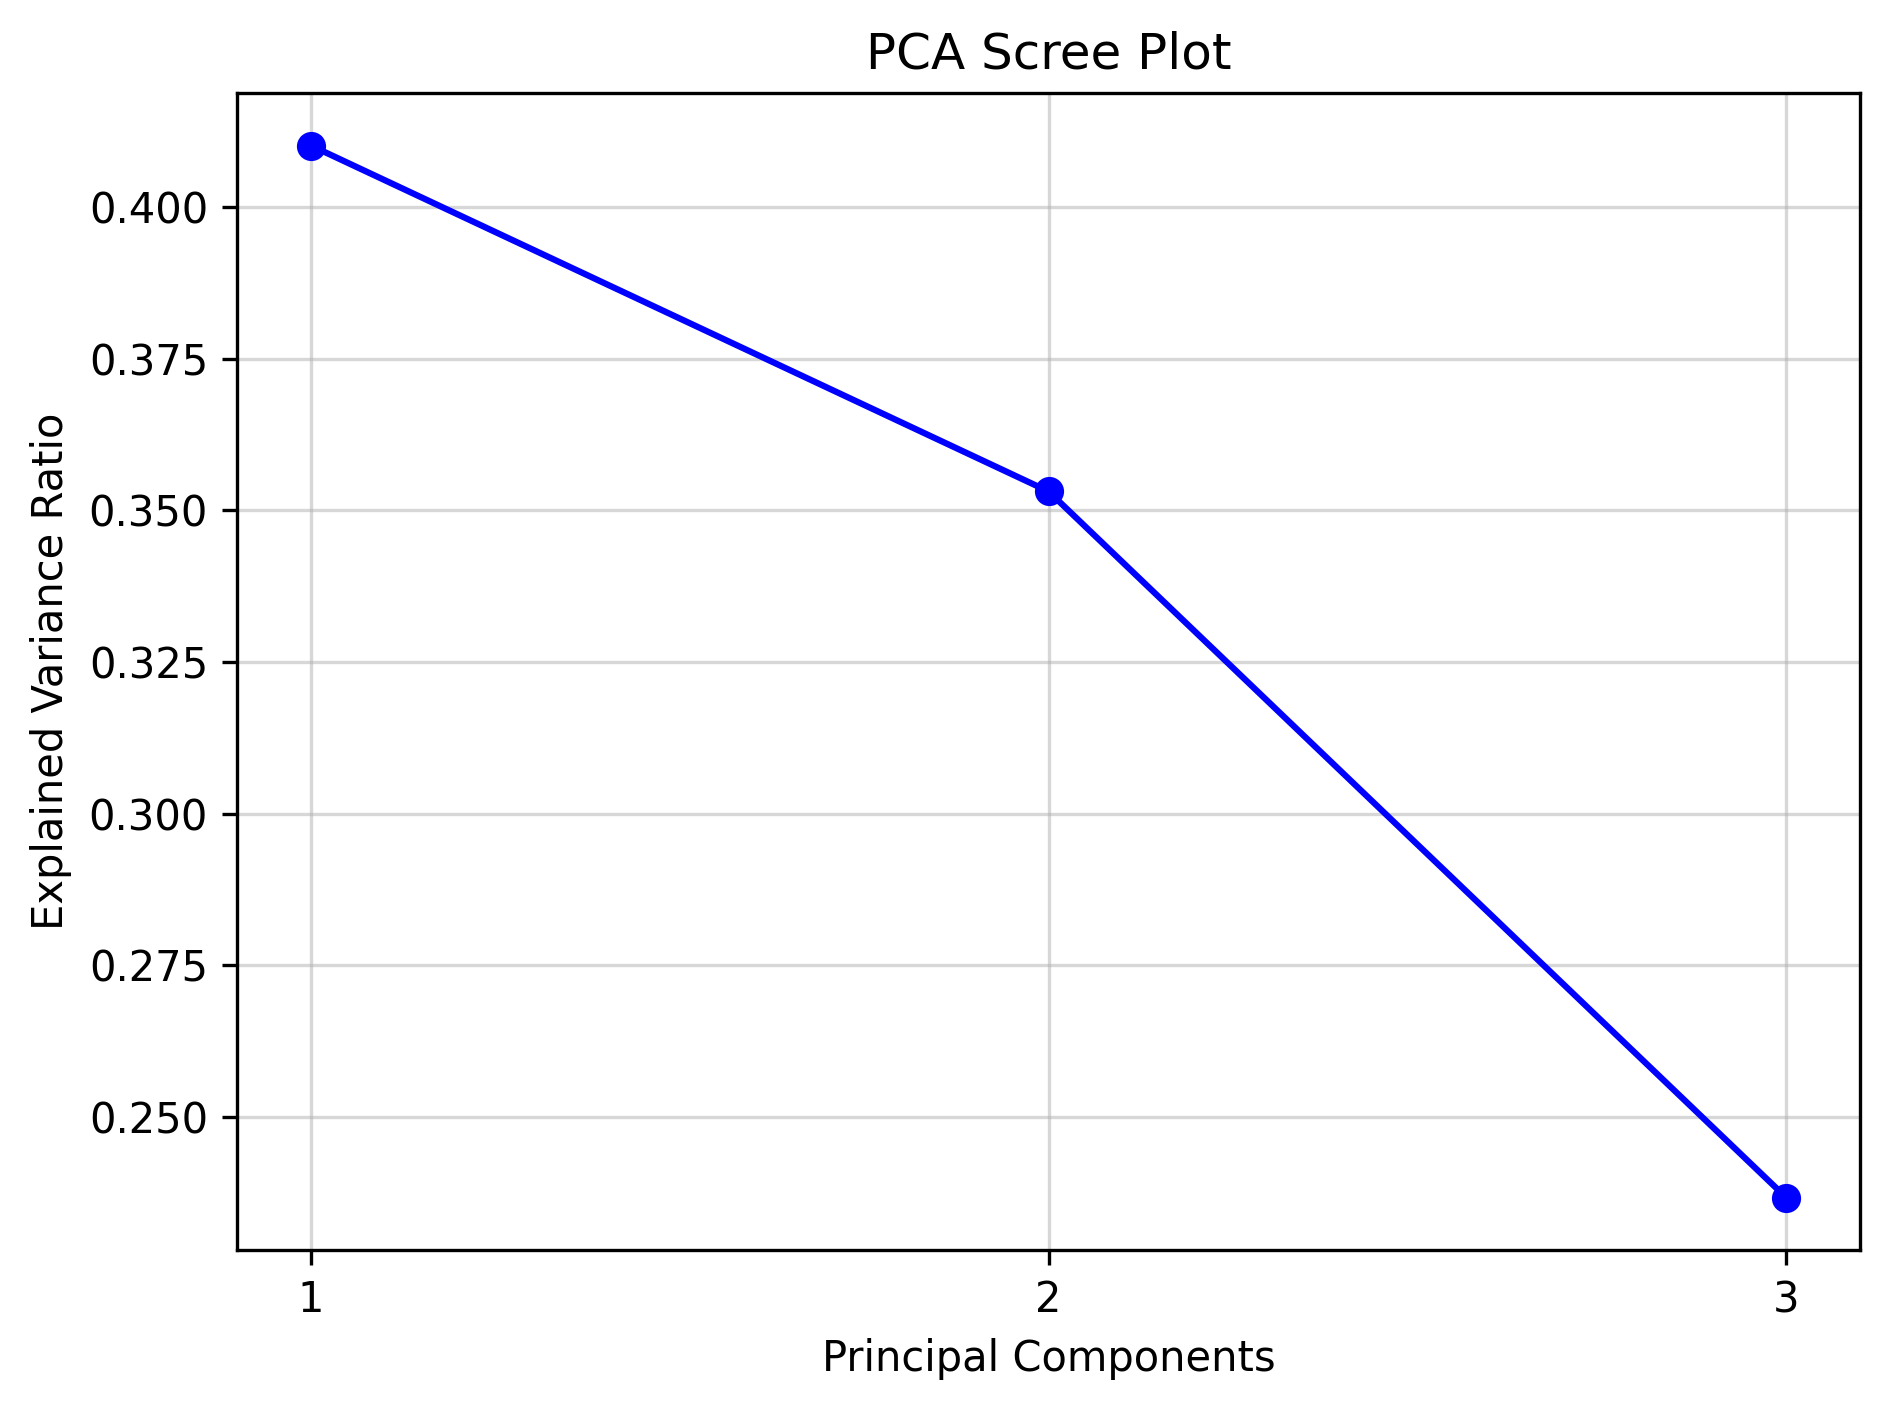

In [8]:
scree_plot(pca_data_mc_m67)

### PC Contributions

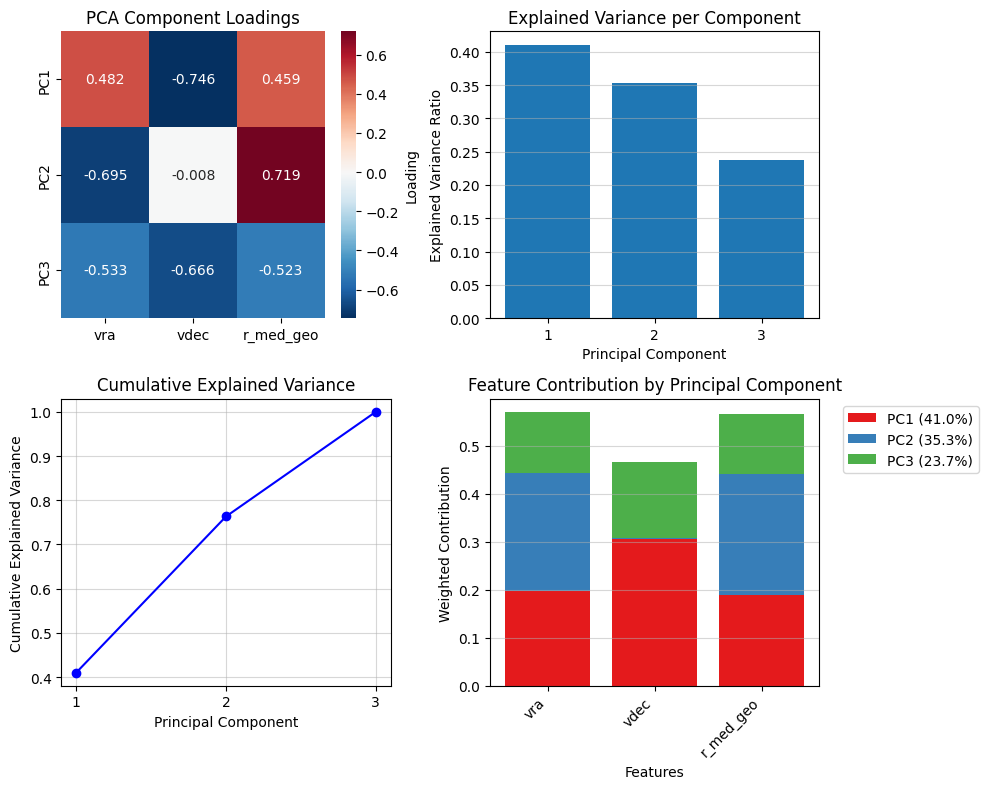

In [9]:
pc_contributions(pca_data_mc_m67)

### PCs Projected onto Data


Trimmed, scaled data + PCs



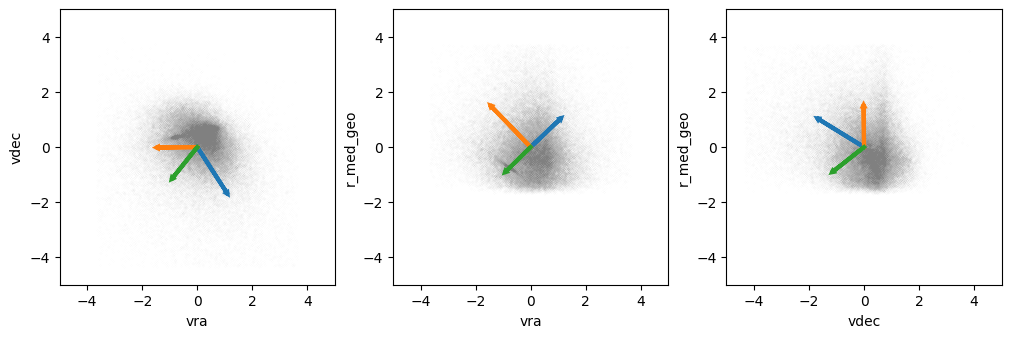

In [10]:
# NOTE: I don't entire understand this code yet unfortunately, so I will have to come back to it

print()
start = "\033[1m" # beginning of bold text
end = "\033[0;0m" # end of bold text
print(f'{start}Trimmed, scaled data + PCs{end}\n')
#display(HTML('<b>Trimmed, scaled data + PCs</b>')) ==> in case you want to use HTML, but will need to import it

fig, axs = plt.subplots(1, len(pca_data_mc_m67.columns), figsize=(10,8), sharex=True, constrained_layout=True)

pca_vector_panel(axs[0], pca_data_scaled, pca, 0, 1, 'vra', 'vdec')
pca_vector_panel(axs[1], pca_data_scaled, pca, 0, 2, 'vra','r_med_geo')
pca_vector_panel(axs[2], pca_data_scaled, pca, 1, 2, 'vdec', 'r_med_geo')

plt.show()
plt.close()

### KDE

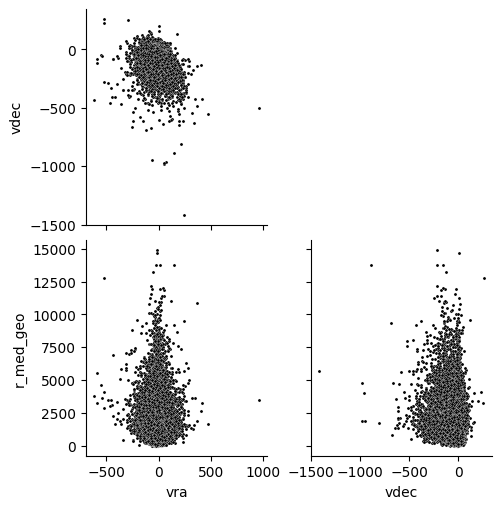

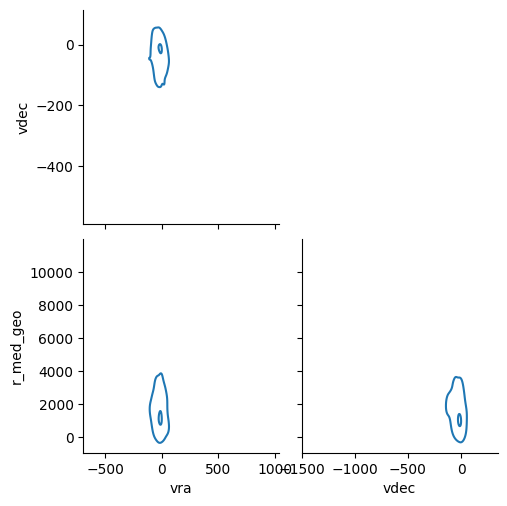

In [11]:
kde_plot(pca_data_mc_m67)

## 2 Components

### Define Data

In [12]:
pca_data_mc_m67 = mc_m67[['vra', 'vdec', 'r_med_geo']].copy()
pca_data_mc_m67

,vra,vdec,r_med_geo
1,-27.507460,68.208368,1299.076538
2,-25.254761,7.127286,259.710754
3,-29.412146,-4.910378,538.822510
4,-43.034580,-75.968074,1644.195190
5,-11.713372,20.052976,844.427246
...,...,...,...
115521,-46.562558,-25.575187,1680.500244
115522,36.645438,-131.039794,2229.045654
115523,16.404410,-43.896490,2228.217285
115524,-14.381212,10.725368,1570.699341


### Applying PCA

In [13]:
sigma = 3
pca_data_mc_m67 = pca_data_mc_m67
n_components = 2
apply_pca(sigma, pca_data_mc_m67, n_components)

Shape before trimming: (85861, 3)
Shape after trimming: (82432, 3)
We have effectively removed 3429 stars to ease computation. 

Column 0: Mean = 0.00, Variance = 1.00
Column 1: Mean = 0.00, Variance = 1.00
Column 2: Mean = 0.00, Variance = 1.00
Marix Mean = 0.00, Matrix Variance = 1.00 

Number of principal components: 2 

Explained variance ratio: [0.53733883 0.46266117] 

Original dataset:


,vra,vdec,r_med_geo
1,-27.507460,68.208368,1299.076538
2,-25.254761,7.127286,259.710754
3,-29.412146,-4.910378,538.822510
4,-43.034580,-75.968074,1644.195190
5,-11.713372,20.052976,844.427246
...,...,...,...
115521,-46.562558,-25.575187,1680.500244
115522,36.645438,-131.039794,2229.045654
115523,16.404410,-43.896490,2228.217285
115524,-14.381212,10.725368,1570.699341



Trimmed and scaled dataset:


,vra,vdec,r_med_geo
0,-0.274149,2.651412,-0.206556
1,-0.204367,0.913569,-1.414478
2,-0.333150,0.571081,-1.090102
3,-0.755129,-1.450611,0.194531
4,0.215102,1.281323,-0.734937
...,...,...,...
82427,-0.864415,-0.016862,0.236724
82428,1.713103,-3.017479,0.874228
82429,1.086101,-0.538129,0.873265
82430,0.132461,1.015940,0.109116



PC dataframe:


,PC1,PC2
0,-2.205852,0.022201
1,-1.429296,-0.881215
2,-1.086961,-0.555982
3,0.807821,0.675844
4,-1.189772,-0.687370
...,...,...
82427,-0.295609,0.771340
82428,3.479190,-0.540286
82429,1.325941,-0.123678
82430,-0.644330,-0.021368



PCA transformation coefficients matrix:


,vra,vdec,r_med_geo
PC1,0.482169,-0.746360,0.458760
PC2,-0.695389,-0.007547,0.718594


### Plotting PCs

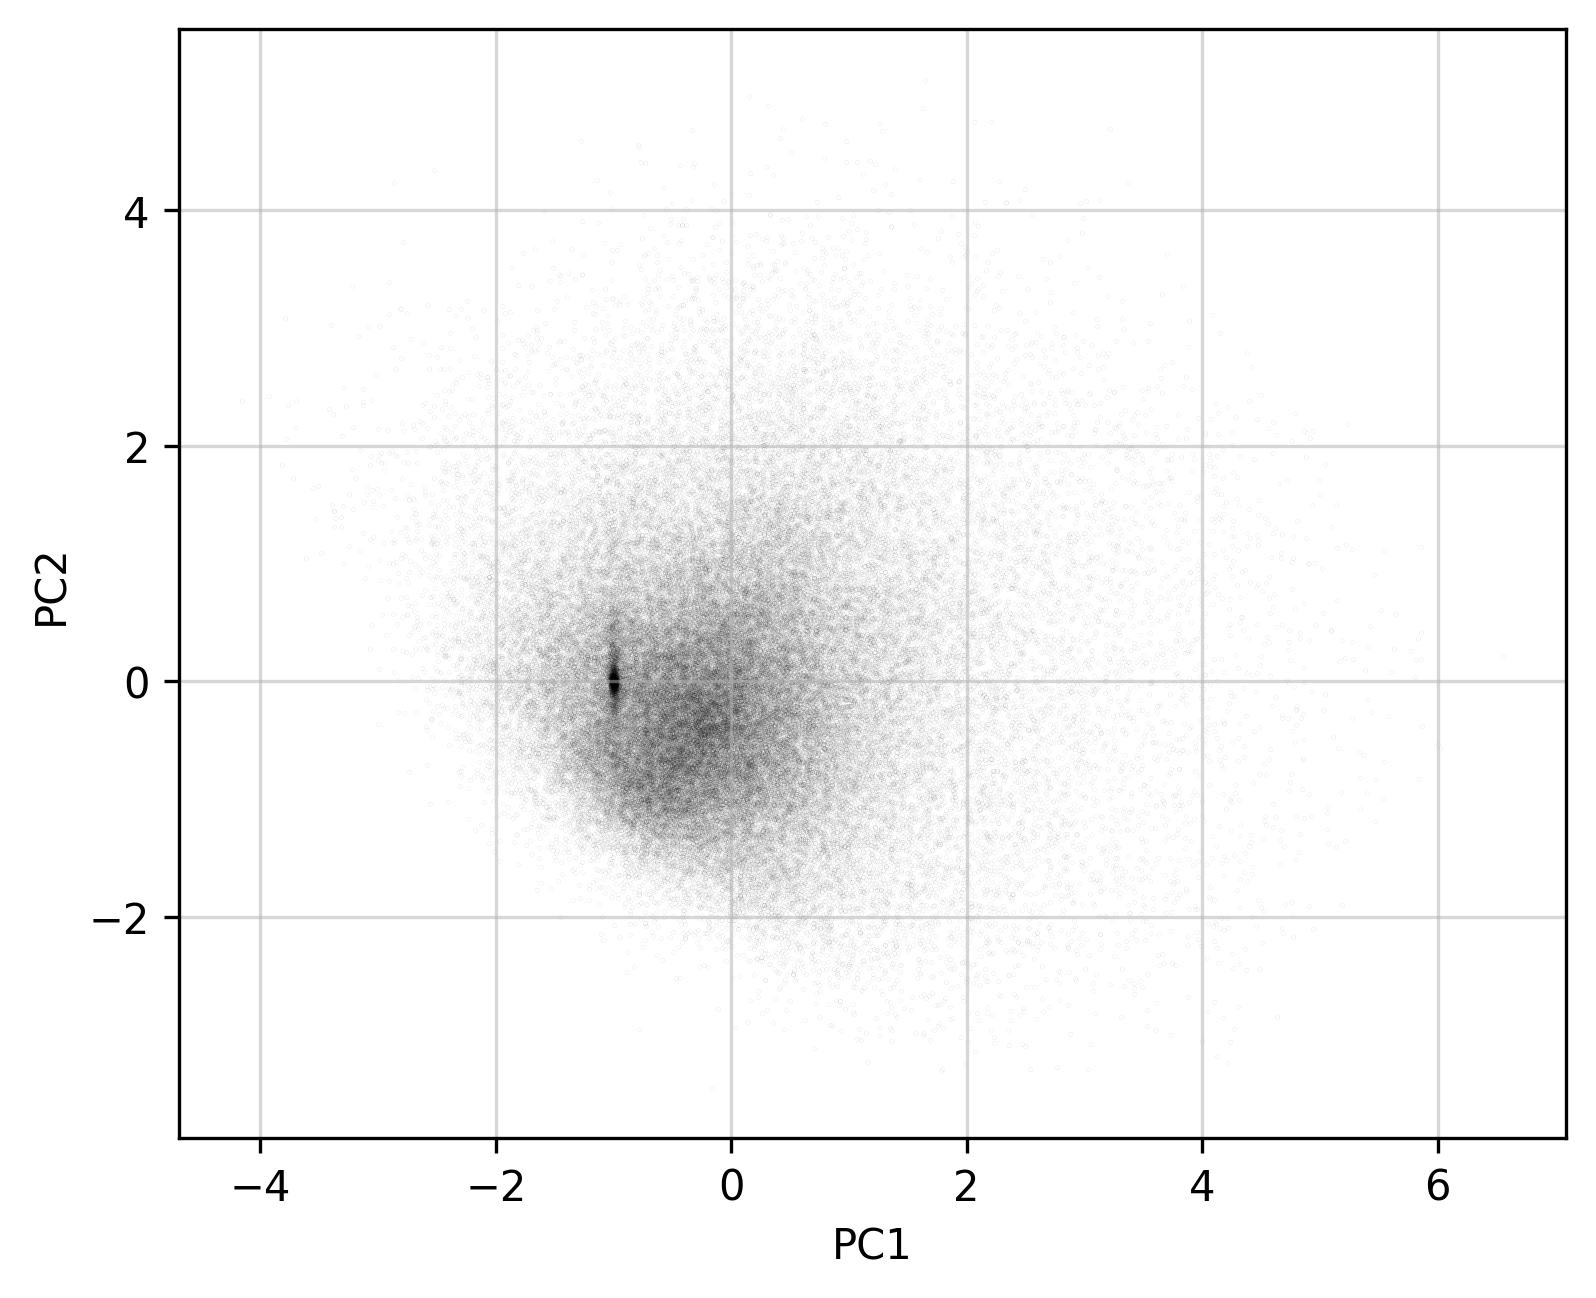

In [14]:
# PC vs. PC

pc1 = pc_df.PC1
pc2 = pc_df.PC2

plt.figure(dpi=300)

plt.scatter(pc1, pc2, s=0.001, alpha=0.3, c='0')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.gca().set_aspect(1)
plt.grid(alpha=0.5)

plt.show()
plt.close()

### PC Contributions

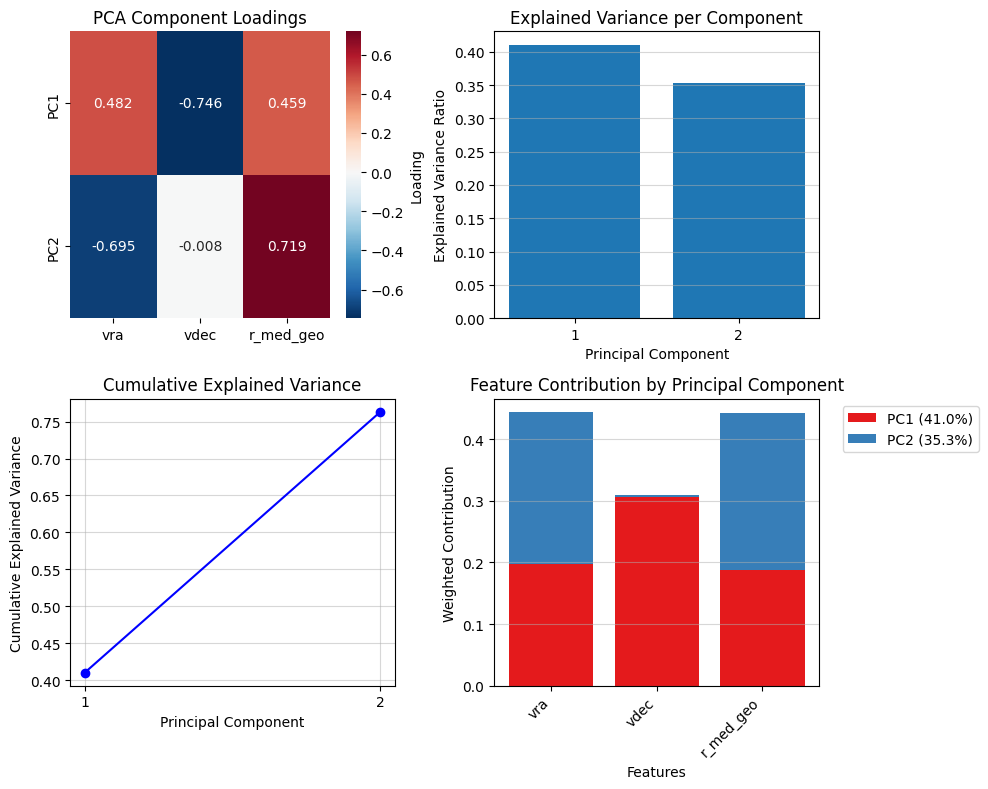

In [15]:
pc_contributions(pca_data_mc_m67)

### PCs Projected onto Data


Trimmed, scaled data + PCs



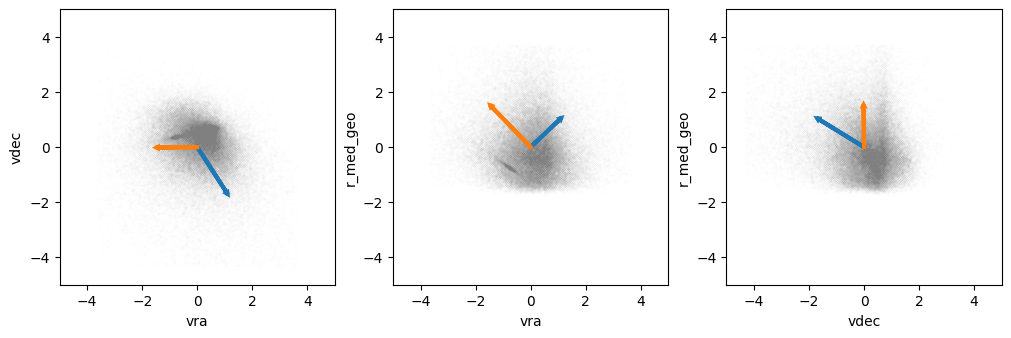

In [16]:
# NOTE: I don't entire understand this code yet unfortunately, so I will have to come back to it

print()
start = "\033[1m" # beginning of bold text
end = "\033[0;0m" # end of bold text
print(f'{start}Trimmed, scaled data + PCs{end}\n')
#display(HTML('<b>Trimmed, scaled data + PCs</b>')) ==> in case you want to use HTML, but will need to import it

fig, axs = plt.subplots(1, len(pca_data_mc_m67.columns), figsize=(10,8), sharex=True, constrained_layout=True)

pca_vector_panel(axs[0], pca_data_scaled, pca, 0, 1, 'vra', 'vdec')
pca_vector_panel(axs[1], pca_data_scaled, pca, 0, 2, 'vra','r_med_geo')
pca_vector_panel(axs[2], pca_data_scaled, pca, 1, 2, 'vdec', 'r_med_geo')

plt.show()
plt.close()

## Exploring w/ Different Parameters

In [17]:
mc_m67.columns

Index(['SOURCE_ID', 'ra', 'dec', 'parallax', 'pmra', 'pmdec', 'ruwe',
       'phot_g_mean_flux', 'phot_g_mean_mag', 'phot_g_mean_flux_error',
       'phot_bp_mean_flux', 'phot_bp_mean_mag', 'phot_bp_mean_flux_error',
       'phot_rp_mean_flux', 'phot_rp_mean_mag', 'phot_bp_mean_flux_error_2',
       'bp_rp', 'bp_g', 'g_rp', 'radial_velocity', 'radial_velocity_error',
       'l', 'b', 'teff_gspphot', 'logg_gspphot', 'mh_gspphot',
       'distance_gspphot', 'r_med_geo', 'r_med_photogeo', 'flag',
       'fidelity_v2', 'cluster_flag', 'vra', 'vdec', 'MG', 'distance_raw',
       'vra_raw', 'vdec_raw', 'MG_raw'],
      dtype='object')

In [18]:
# You can plot any of the motion/light columns against each other to see their scaling (e.g. pmdec vs. pmra)

columns_motion = ['parallax', 'pmra', 'pmdec', 'r_med_geo', 'vra', 'vdec', 'radial_velocity']
columns_light = ['phot_g_mean_flux', 'phot_g_mean_mag', 'bp_rp', 'teff_gspphot', 'MG']
columns_liz = ['vra', 'vdec', 'r_med_geo', 'radial_velocity']
pca_data_mc_m67 = mc_m67[columns_motion].copy()
pca_data_mc_m67

,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
1,0.673193,-4.467221,11.077062,1299.076538,-27.507460,68.208368,NaN
2,3.808344,-20.515164,5.789698,259.710754,-25.254761,7.127286,NaN
3,2.102317,-11.516026,-1.922608,538.822510,-29.412146,-4.910378,NaN
4,0.633316,-5.521866,-9.747638,1644.195190,-43.034580,-75.968074,NaN
5,1.372819,-2.926452,5.010006,844.427246,-11.713372,20.052976,NaN
...,...,...,...,...,...,...,...
115521,0.338400,-5.845476,-3.210716,1680.500244,-46.562558,-25.575187,NaN
115522,-1.269681,3.468348,-12.402405,2229.045654,36.645438,-131.039794,NaN
115523,0.307591,1.553191,-4.156176,2228.217285,16.404410,-43.896490,NaN
115524,0.734975,-1.931631,1.440591,1570.699341,-14.381212,10.725368,NaN


In [19]:
sigma = 3
pca_data_mc_m67 = pca_data_mc_m67
n_components = len(pca_data_mc_m67.columns)
apply_pca(sigma, pca_data_mc_m67, n_components)

Shape before trimming: (85861, 7)
Shape after trimming: (5924, 7)
We have effectively removed 79937 stars to ease computation. 

Column 0: Mean = 0.00, Variance = 1.00
Column 1: Mean = 0.00, Variance = 1.00
Column 2: Mean = 0.00, Variance = 1.00
Column 3: Mean = 0.00, Variance = 1.00
Column 4: Mean = 0.00, Variance = 1.00
Column 5: Mean = 0.00, Variance = 1.00
Column 6: Mean = 0.00, Variance = 1.00
Marix Mean = 0.00, Matrix Variance = 1.00 

Number of principal components: 7 

Explained variance ratio: [0.37191018 0.26622049 0.20493395 0.08420767 0.03845701 0.02169558
 0.01257512] 

Original dataset:


,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
1,0.673193,-4.467221,11.077062,1299.076538,-27.507460,68.208368,NaN
2,3.808344,-20.515164,5.789698,259.710754,-25.254761,7.127286,NaN
3,2.102317,-11.516026,-1.922608,538.822510,-29.412146,-4.910378,NaN
4,0.633316,-5.521866,-9.747638,1644.195190,-43.034580,-75.968074,NaN
5,1.372819,-2.926452,5.010006,844.427246,-11.713372,20.052976,NaN
...,...,...,...,...,...,...,...
115521,0.338400,-5.845476,-3.210716,1680.500244,-46.562558,-25.575187,NaN
115522,-1.269681,3.468348,-12.402405,2229.045654,36.645438,-131.039794,NaN
115523,0.307591,1.553191,-4.156176,2228.217285,16.404410,-43.896490,NaN
115524,0.734975,-1.931631,1.440591,1570.699341,-14.381212,10.725368,NaN



Trimmed and scaled dataset:


,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
0,1.016909,-0.337195,-1.373027,-0.841319,0.120171,-0.619049,-0.145758
1,-0.588682,-0.051047,1.343042,0.152411,-0.297933,1.812717,-0.106937
2,-1.021376,0.385769,0.409156,1.181077,0.122423,0.205819,0.775053
3,-1.039620,0.365227,-0.111377,1.320786,0.040552,-1.171381,-0.066843
4,2.157875,-0.961432,-0.492722,-1.047146,0.020689,0.149237,-0.000711
...,...,...,...,...,...,...,...
5919,-0.407021,-0.624667,0.259009,-0.074323,-0.897910,0.205547,0.380479
5920,-0.839634,0.022554,-0.424958,0.639949,-0.449695,-1.364272,1.884978
5921,-0.559283,1.110923,0.329485,0.117919,1.406714,0.255300,-1.225789
5922,-1.222166,0.330410,0.387233,2.278990,-0.302573,-0.045869,-0.146500



PC dataframe:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,1.078587,-1.351448,1.044116,-0.057544,0.062788,-0.147682,-0.225228
1,-1.497810,0.265224,-1.725100,0.260453,-0.159107,-0.356860,-0.228116
2,-0.679999,1.600927,-0.132898,-0.570423,0.095491,-0.041019,-0.182266
3,0.324084,1.837978,0.796663,0.267374,0.161401,0.302556,0.205867
4,0.260417,-2.467647,0.301576,-0.176647,0.786797,0.183990,-0.103040
...,...,...,...,...,...,...,...
5919,-1.143008,-0.080587,0.357644,0.246212,-0.326156,-0.094631,0.070134
5920,-0.547185,1.166296,1.858220,-1.208976,-0.360347,0.306507,0.337879
5921,1.374242,0.902823,-1.507314,0.324204,-0.209593,0.145242,-0.265023
5922,-0.632969,2.391152,0.051689,0.496992,0.797901,-0.229647,-0.066390



PCA transformation coefficients matrix:


,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
PC1,1.748361e-01,0.446916,-0.421875,-0.142852,0.513454,-0.372209,-0.411264
PC2,-6.430827e-01,0.335529,0.110142,0.649082,0.100885,-0.170716,0.033245
PC3,-3.375791e-02,-0.319867,-0.561087,0.106937,-0.345974,-0.604574,0.291691
PC4,-1.850473e-01,-0.336303,0.043289,0.060263,-0.327646,-0.067459,-0.857467
PC5,6.731958e-01,-0.097276,0.020518,0.724554,0.050963,0.055702,-0.079026
PC6,-5.546388e-07,-0.459728,0.528549,-0.065672,0.489454,-0.512163,0.055644
PC7,2.594266e-01,0.501457,0.461966,-0.118016,-0.506926,-0.443669,-0.009026


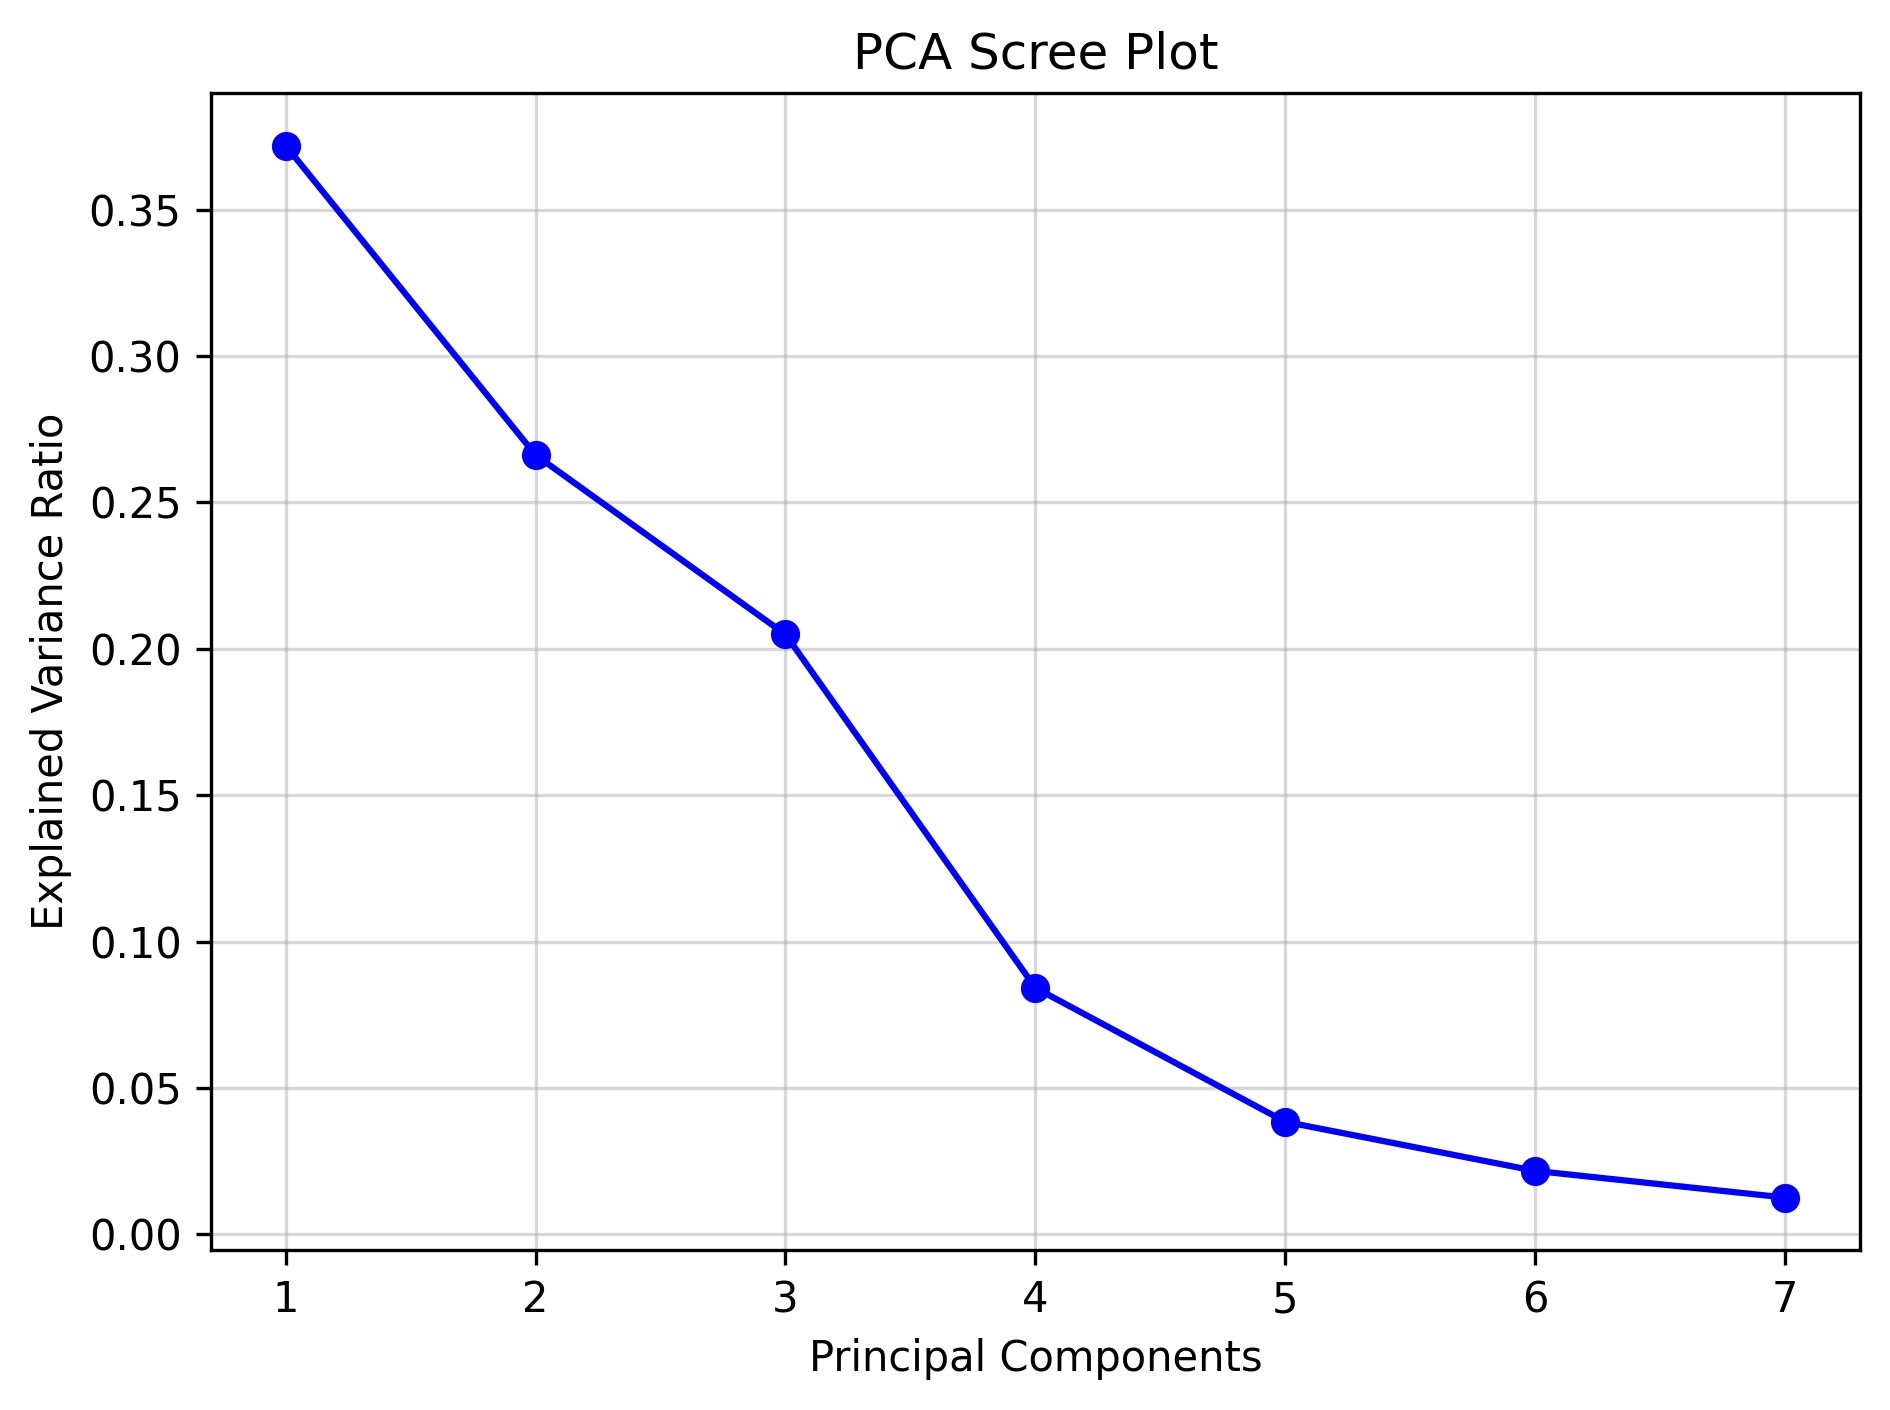

In [20]:
scree_plot(pca_data_mc_m67)

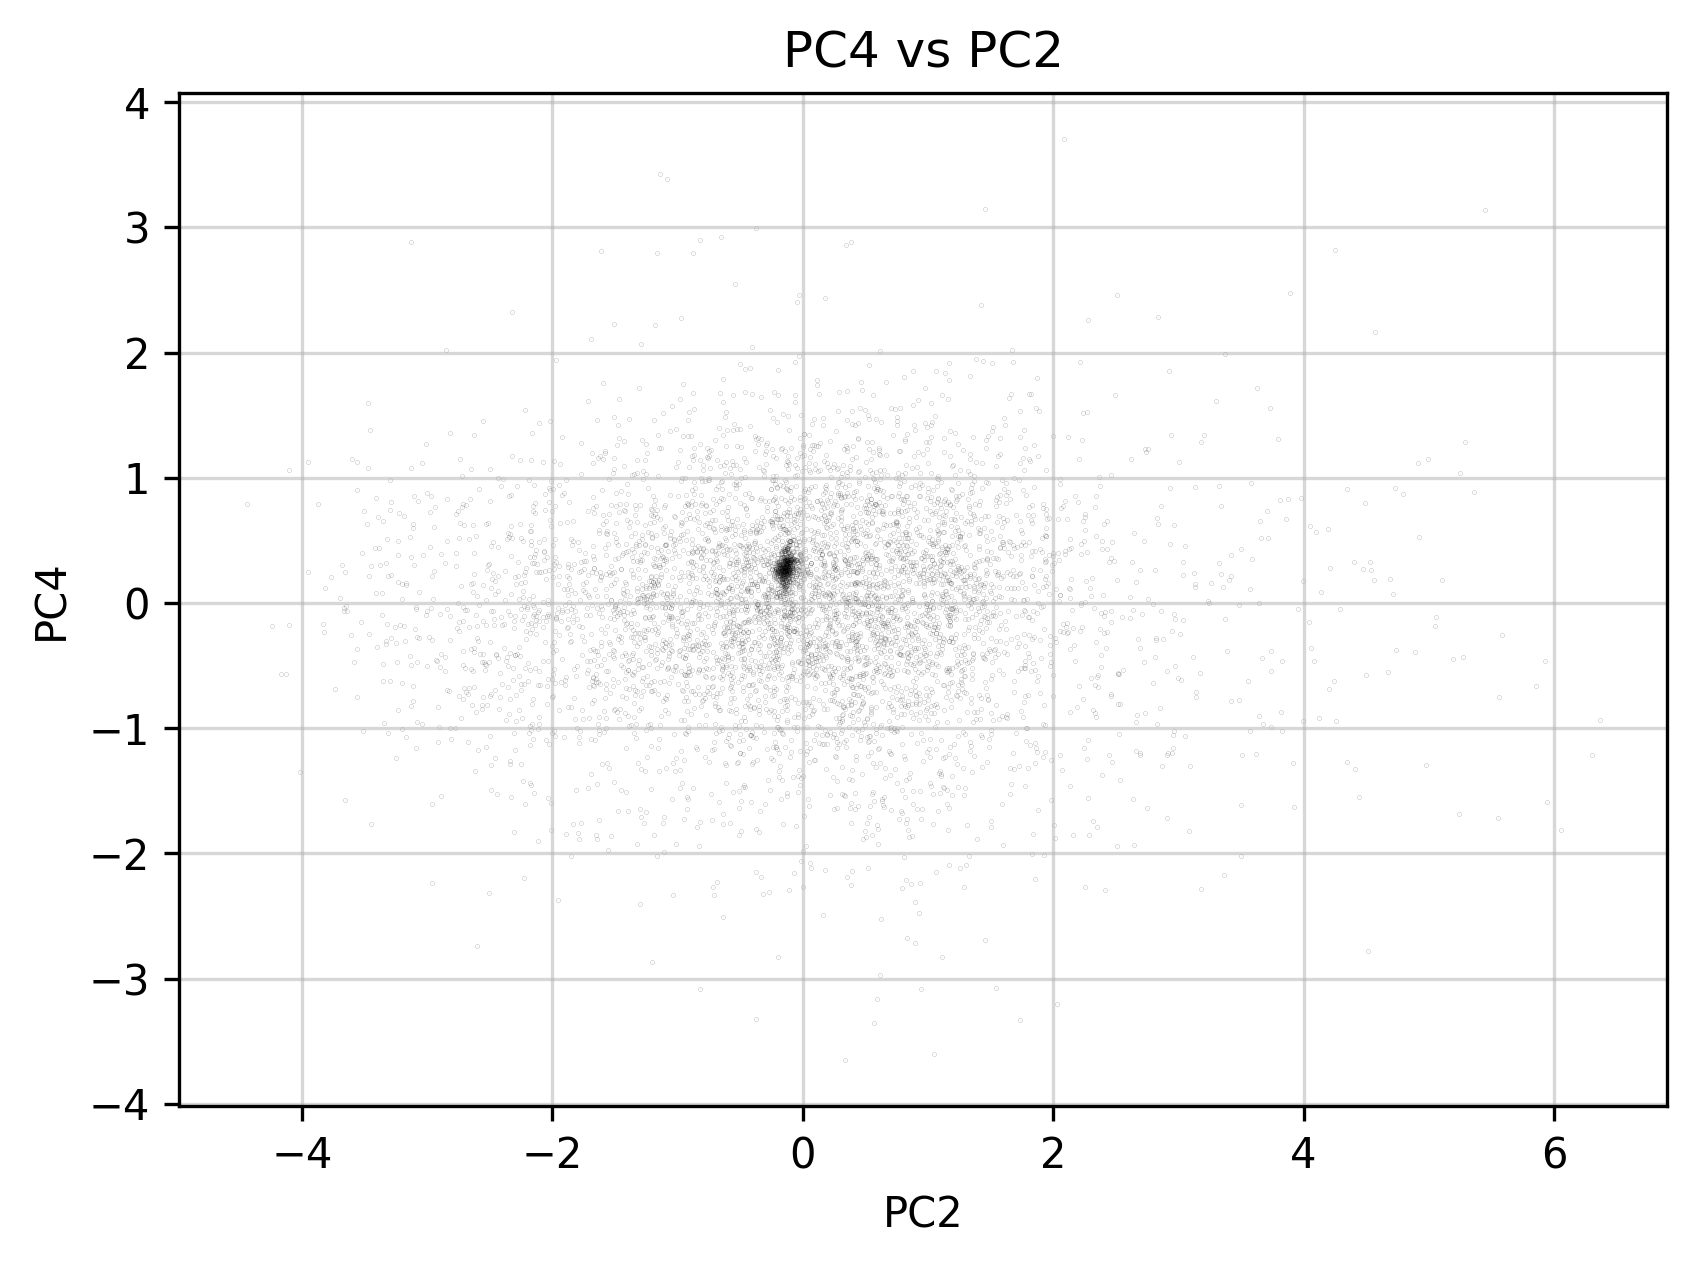

In [21]:
x = pc_df.PC2
y = pc_df.PC4

pc_vs_pc(x, y, 0.01)

# Blanco 1

## Define Data

In [22]:
# Setting up the data we will actually use for PCA (using entire dataset):
pca_data_blanco1 = mc_blanco1[columns_motion].copy()
pca_data_blanco1

,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
7,-0.102500,-2.918864,-11.107717,1975.989502,-27.338634,-104.036993,NaN
8,-0.048911,4.022452,-4.073233,2224.760254,42.418220,-42.953718,NaN
10,0.267992,15.697833,-4.801356,3154.718262,234.735422,-71.796433,NaN
11,0.609655,16.548270,-3.036656,1562.191650,122.536438,-22.485799,NaN
12,1.035545,12.686734,-7.109915,1016.069885,61.101485,-34.242569,NaN
...,...,...,...,...,...,...,...
62420,0.270329,1.511676,-0.492036,2154.209717,15.435654,-5.024153,NaN
62421,1.155257,4.304247,-12.439239,1046.568848,21.352237,-61.707783,NaN
62422,3.582866,8.236941,-18.571744,363.674957,14.198998,-32.014331,NaN
62423,0.267630,-0.237556,-4.747927,3149.406738,-3.546282,-70.877947,NaN


## Applying PCA

In [23]:
sigma = 3
pca_data_blanco1 = pca_data_blanco1
n_components = len(pca_data_blanco1.columns)
apply_pca(sigma, pca_data_blanco1, n_components)

Shape before trimming: (47739, 7)
Shape after trimming: (2909, 7)
We have effectively removed 44830 stars to ease computation. 

Column 0: Mean = 0.00, Variance = 1.00
Column 1: Mean = 0.00, Variance = 1.00
Column 2: Mean = 0.00, Variance = 1.00
Column 3: Mean = 0.00, Variance = 1.00
Column 4: Mean = 0.00, Variance = 1.00
Column 5: Mean = 0.00, Variance = 1.00
Column 6: Mean = 0.00, Variance = 1.00
Marix Mean = 0.00, Matrix Variance = 1.00 

Number of principal components: 7 

Explained variance ratio: [0.33111101 0.2621189  0.18473092 0.14088199 0.04511915 0.02221327
 0.01382477] 

Original dataset:


,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
7,-0.102500,-2.918864,-11.107717,1975.989502,-27.338634,-104.036993,NaN
8,-0.048911,4.022452,-4.073233,2224.760254,42.418220,-42.953718,NaN
10,0.267992,15.697833,-4.801356,3154.718262,234.735422,-71.796433,NaN
11,0.609655,16.548270,-3.036656,1562.191650,122.536438,-22.485799,NaN
12,1.035545,12.686734,-7.109915,1016.069885,61.101485,-34.242569,NaN
...,...,...,...,...,...,...,...
62420,0.270329,1.511676,-0.492036,2154.209717,15.435654,-5.024153,NaN
62421,1.155257,4.304247,-12.439239,1046.568848,21.352237,-61.707783,NaN
62422,3.582866,8.236941,-18.571744,363.674957,14.198998,-32.014331,NaN
62423,0.267630,-0.237556,-4.747927,3149.406738,-3.546282,-70.877947,NaN



Trimmed and scaled dataset:


,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
0,-0.541984,0.998058,-1.784492,-0.024193,1.359275,-1.941021,1.725616
1,-0.121554,0.312653,0.714492,-0.323419,0.254117,0.720505,-0.214348
2,-0.875233,-0.465551,0.735851,0.449527,-0.344821,0.839973,-1.764613
3,0.058796,0.126321,0.098514,-0.421056,0.011464,0.258768,-0.321866
4,-0.493282,-0.066576,-0.756980,-0.060810,0.048134,-0.789777,-0.820358
...,...,...,...,...,...,...,...
2904,2.318141,-2.425849,0.709339,-0.878551,-1.275233,0.655894,0.227060
2905,1.923334,0.514202,0.736609,-0.838765,-0.134457,0.670215,0.021512
2906,0.048447,-1.009973,0.552828,-0.415770,-0.925427,0.591014,-0.015907
2907,-1.066806,-0.007857,0.801440,0.855821,0.667270,1.014806,0.711211



PC dataframe:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,1.212078,0.965261,2.588054,1.887763,-0.519262,-0.182360,-0.319977
1,-0.967965,0.271119,-0.489894,-0.160585,-0.270617,-0.070708,-0.052859
2,-0.020402,0.565577,-1.455526,-1.742819,-0.339783,0.112592,0.245441
3,-0.430642,-0.145750,0.007919,-0.327628,-0.244102,-0.043650,-0.038828
4,0.878068,0.211041,0.667829,-0.813777,-0.416551,-0.089699,-0.134899
...,...,...,...,...,...,...,...
2904,-0.415270,-3.078321,-1.263886,-0.134783,1.230433,1.023614,-0.903145
2905,-1.873177,-1.106752,0.231566,-0.054193,0.930108,-0.072767,-0.129694
2906,-0.026314,-1.070976,-1.219112,-0.175526,-0.136770,0.047535,-0.145437
2907,-0.306393,1.304823,-1.259097,0.874017,-0.325116,0.401986,0.284271



PCA transformation coefficients matrix:


,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
PC1,-0.368393,-0.436308,-0.401558,0.380220,-0.271725,-0.541388,0.034191
PC2,-0.461942,0.366032,0.199153,0.504184,0.581077,-0.073828,-0.125164
PC3,0.313004,0.436059,-0.613716,-0.223543,0.318874,-0.427777,-0.024256
PC4,-0.034281,0.046189,0.016803,0.041296,0.116289,0.006832,0.990522
PC5,0.707968,0.018654,0.281687,0.592869,-0.089528,-0.244000,0.006330
PC6,0.221079,-0.555292,-0.367407,0.185781,0.537348,0.428221,-0.034007
PC7,-0.040665,0.417945,-0.455878,0.404408,-0.420182,0.524880,0.015687


## Plotting Trimmed/Scaled Data and PCs

In [24]:
#trimmed_data_plot(pca_data_blanco1, pca_data_trimmed_zscore, 50)

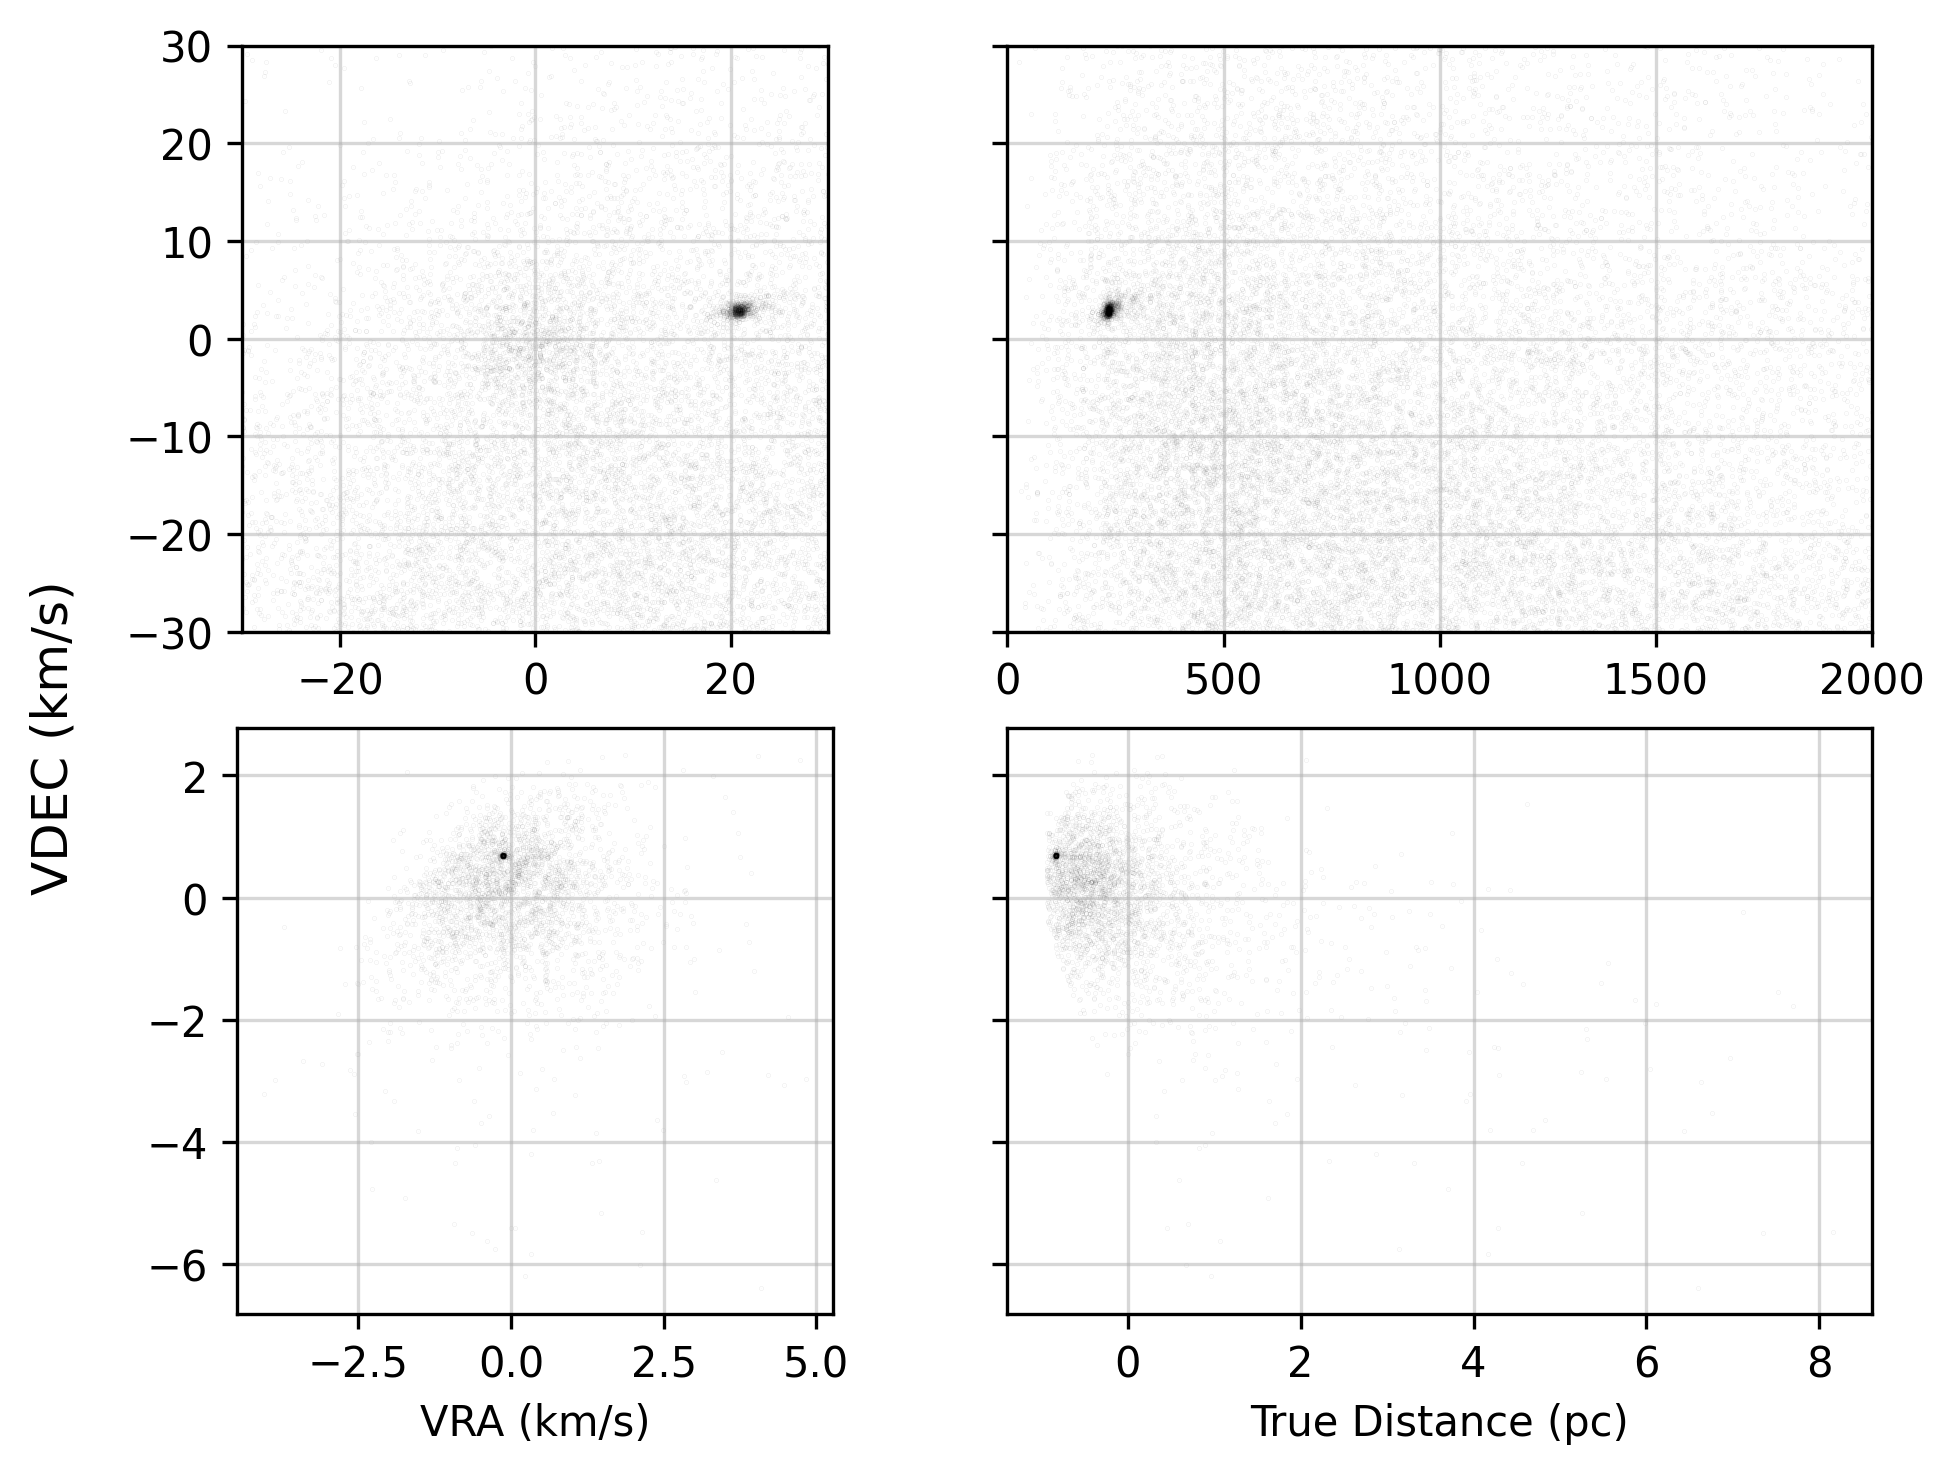

In [25]:
vra = pca_data_blanco1.vra
vdec = pca_data_blanco1.vdec
distance = pca_data_blanco1.r_med_geo

vra_ts = pca_data_scaled_df.vra
vdec_ts = pca_data_scaled_df.vdec
distance_ts = pca_data_scaled_df.r_med_geo

fig, axs = plt.subplots(2, 2, sharey='row', constrained_layout=True, dpi=300)
fig.supylabel('VDEC (km/s)')

# VDEC vs. VRA
ax = axs[0,0]
ax.scatter(vra, vdec, s=0.01, alpha=0.1, c='0')
ax.set_xlim(-30, 30)
ax.set_ylim(-30, 30)
ax.set_aspect(1)
ax.grid(alpha=0.5)

# VDEC vs. Distance
ax = axs[0,1]
ax.scatter(distance, vdec, s=0.01, alpha=0.1, c='0')
ax.set_xlim(0, 2000)
ax.set_aspect('auto')
ax.grid(alpha=0.5)

ax = axs[1,0]
ax.scatter(vra_ts, vdec_ts, s=0.01, alpha=0.1, c='0')
ax.set_xlabel('VRA (km/s)')
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[1,1]
ax.scatter(distance_ts, vdec_ts, s=0.01, alpha=0.1, c='0')
ax.set_xlabel('True Distance (pc)')
ax.set_aspect('auto')
ax.grid(alpha=0.5)

plt.show()
plt.close()

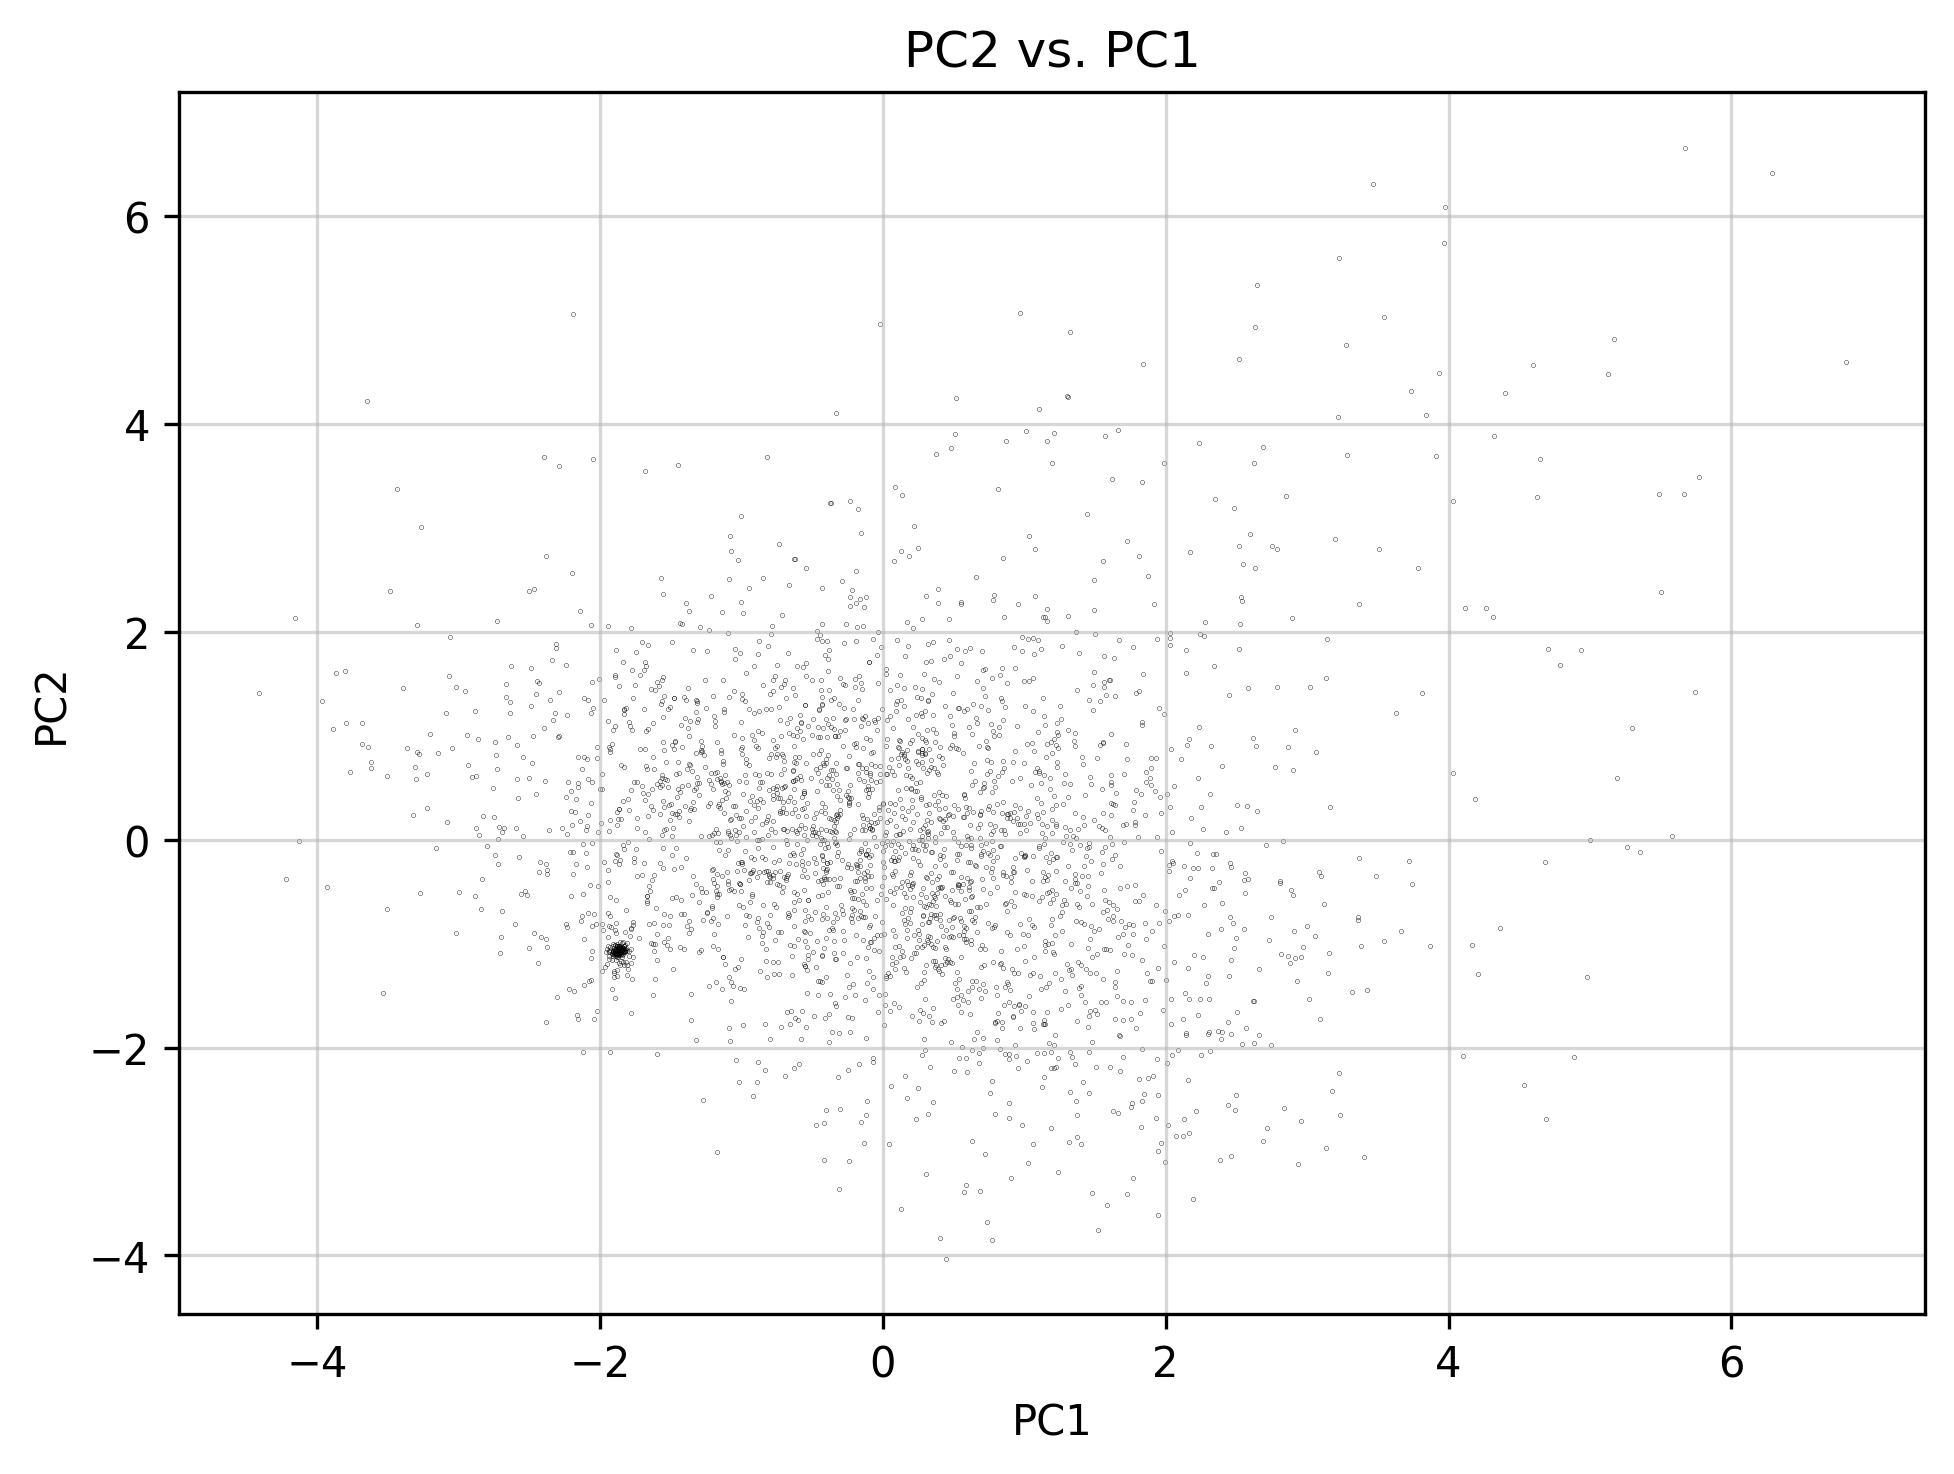

In [26]:
# Single pair of PCS

pc1 = pc_df.PC1
pc2 = pc_df.PC2

fig, axs = plt.subplots(constrained_layout=True, dpi=300)

axs.scatter(pc1, pc2, s=0.01, alpha=1, c='0')
axs.set_xlabel('PC1')
axs.set_ylabel('PC2')
axs.set_title('PC2 vs. PC1')
ax.set_aspect(1)
axs.grid(alpha=0.5)

#plt.savefig('blanco1_pc2-1.png', dpi=1200)
plt.show()
plt.close()

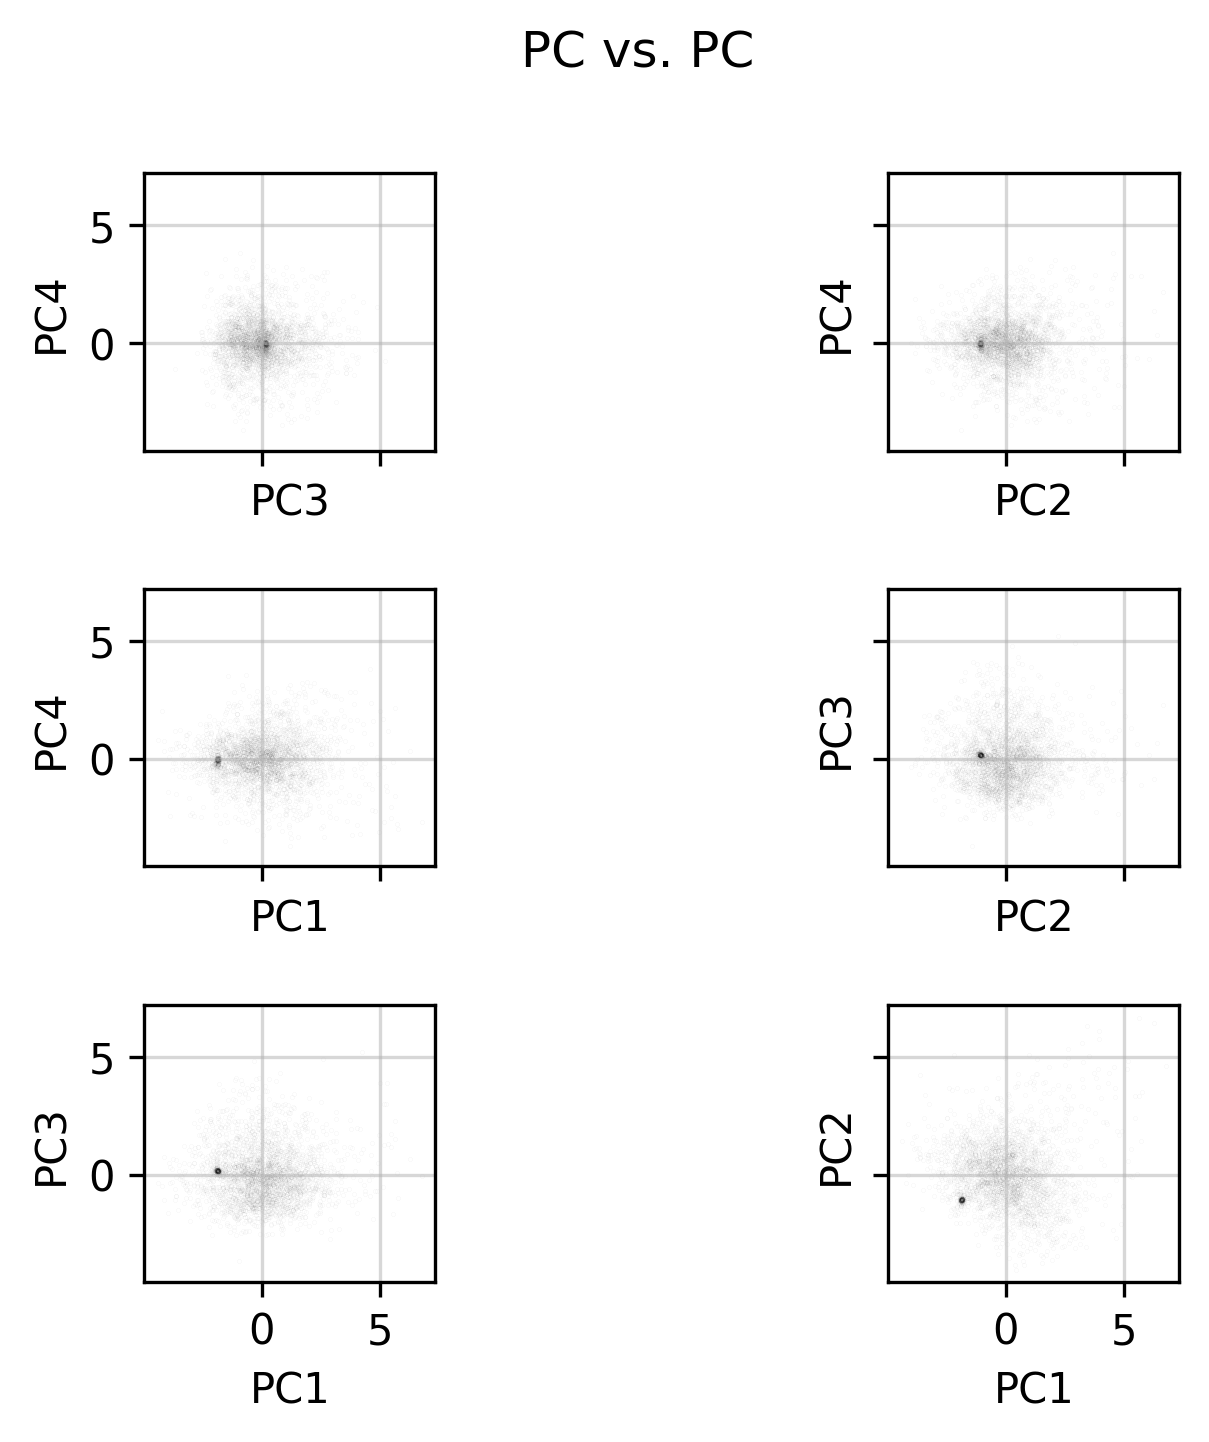

In [27]:
# PCs

pc1 = pc_df.PC1
pc2 = pc_df.PC2
pc3 = pc_df.PC3
pc4 = pc_df.PC4

fig, axs = plt.subplots(3, 2, sharex=True, sharey=True, dpi=300)
fig.suptitle('PC vs. PC')

ax = axs[0, 0]
ax.scatter(pc3, pc4, s=0.0001, alpha=0.5, c='0')
ax.set_xlabel('PC3')
ax.set_ylabel('PC4')
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[0, 1]
ax.scatter(pc2, pc4, s=0.0001, alpha=0.5, c='0')
ax.set_xlabel('PC2')
ax.set_ylabel('PC4')
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[1, 0]
ax.scatter(pc1, pc4, s=0.0001, alpha=0.5, c='0')
ax.set_xlabel('PC1')
ax.set_ylabel('PC4')
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[1, 1]
ax.scatter(pc2, pc3, s=0.0001, alpha=0.5, c='0')
ax.set_xlabel('PC2')
ax.set_ylabel('PC3')
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[2, 0]
ax.scatter(pc1, pc3, s=0.0001, alpha=0.5, c='0')
ax.set_xlabel('PC1')
ax.set_ylabel('PC3')
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[2, 1]
ax.scatter(pc1, pc2, s=0.0001, alpha=0.5, c='0')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_aspect(1)
ax.grid(alpha=0.5)

fig.subplots_adjust(wspace=0, hspace=0.5)

#plt.savefig('dawg.png', dpi=1200)
plt.show()
plt.close()

## Scree Plot

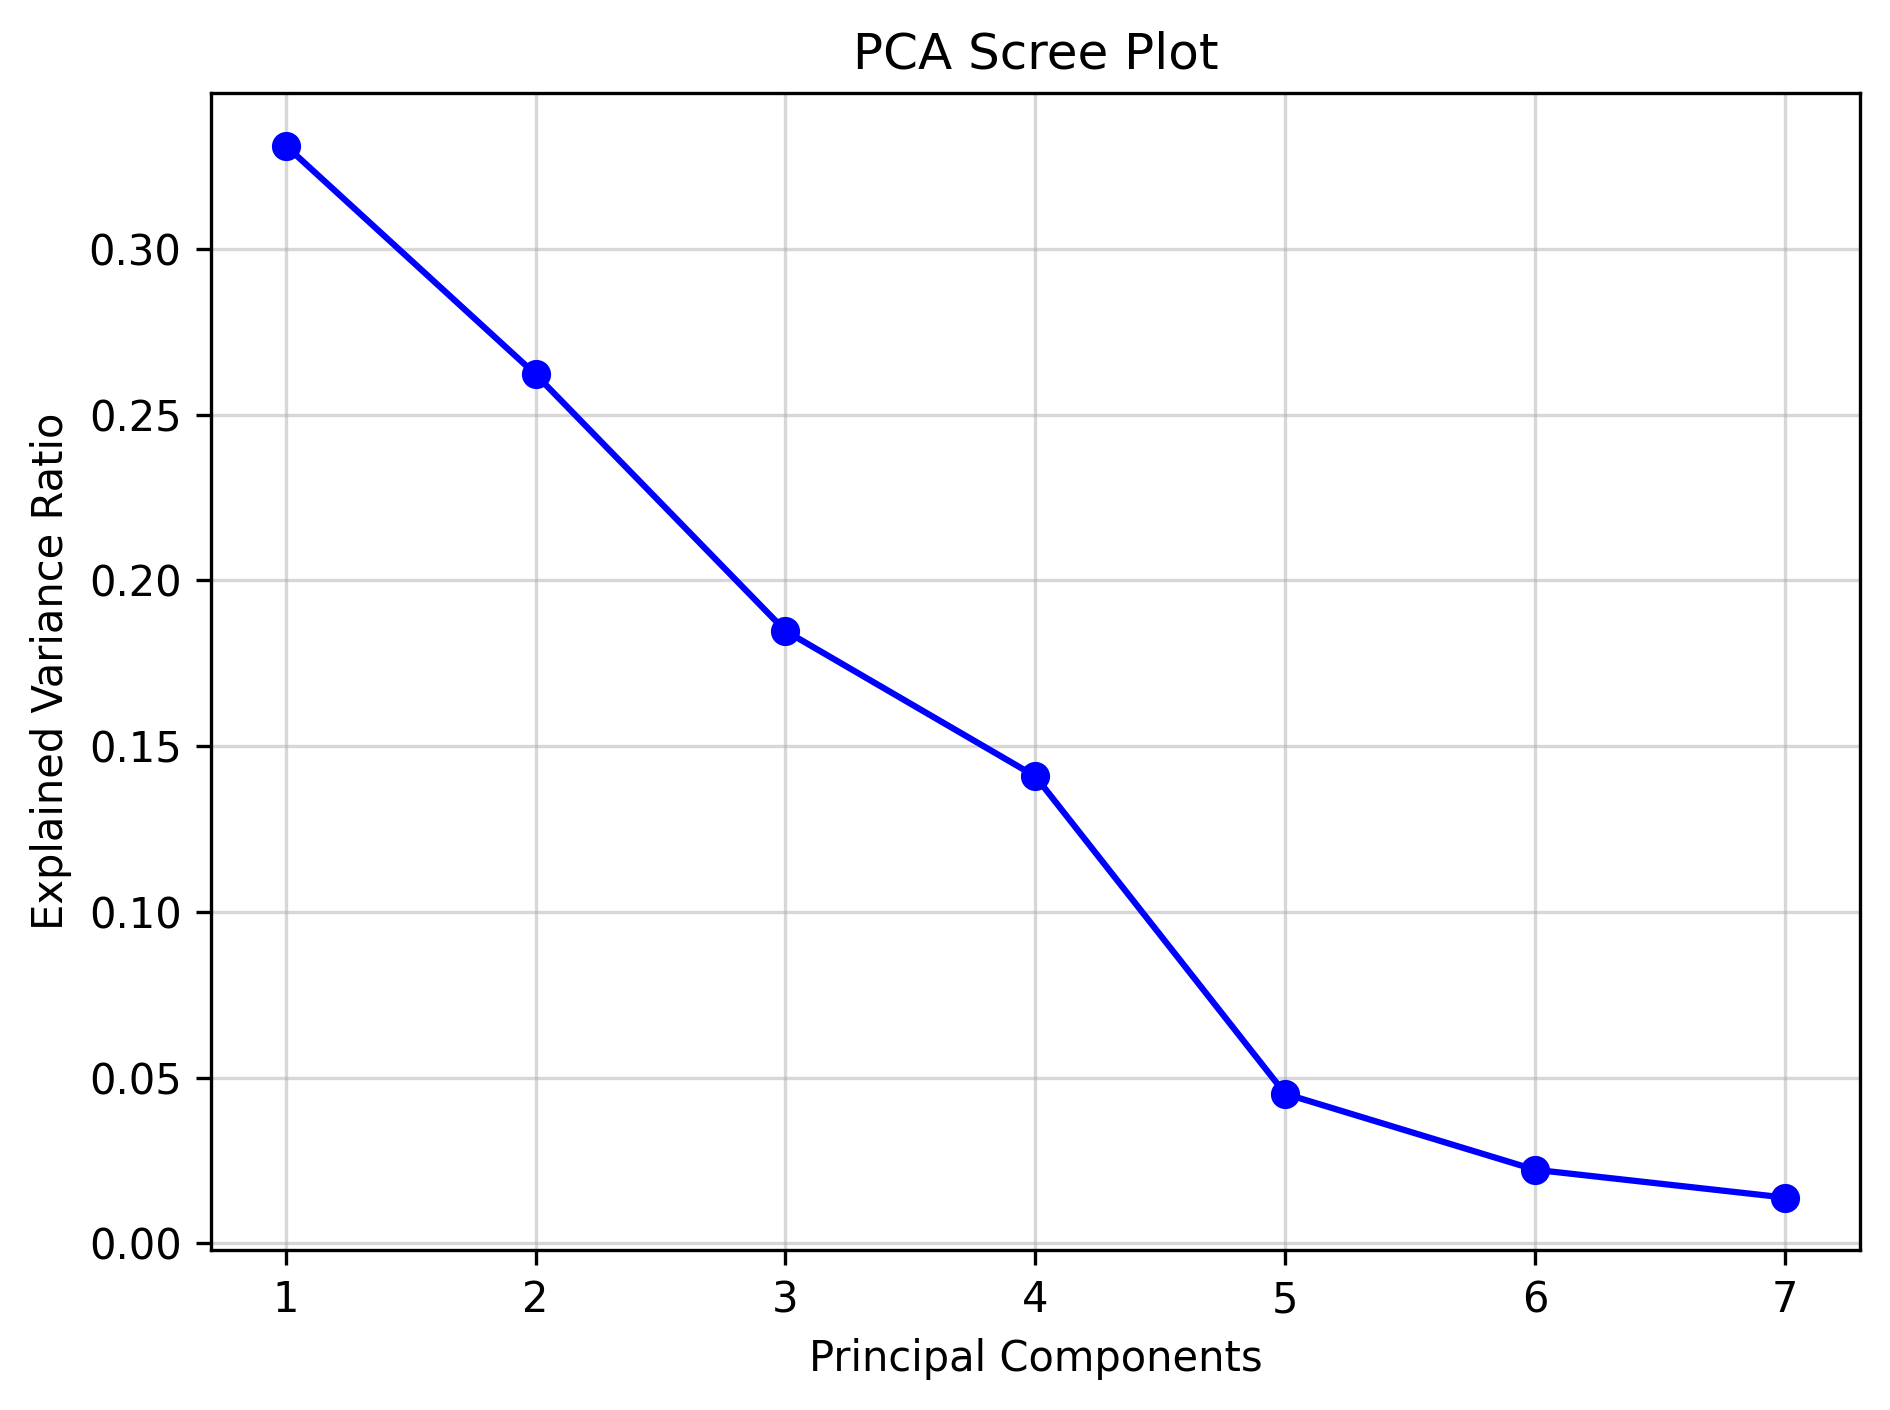

In [28]:
scree_plot(pca_data_blanco1)

## PC Contributions

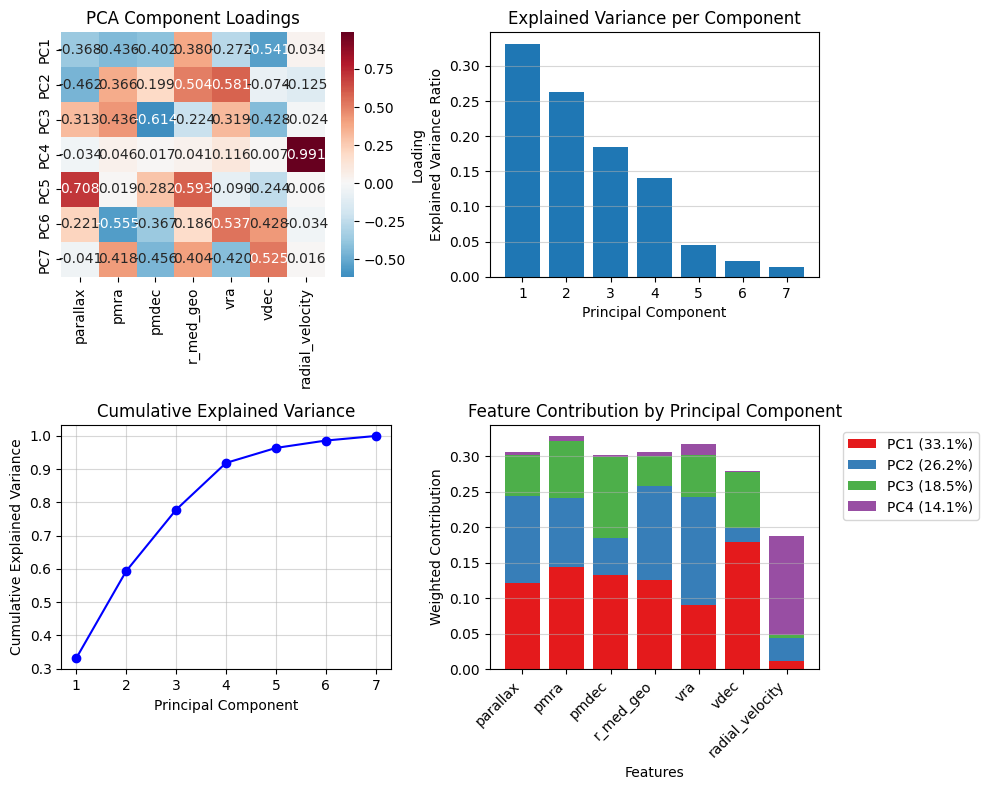

In [29]:
pc_contributions(pca_data_blanco1)

## PCs Projected onto Data


Trimmed, scaled data + PCs



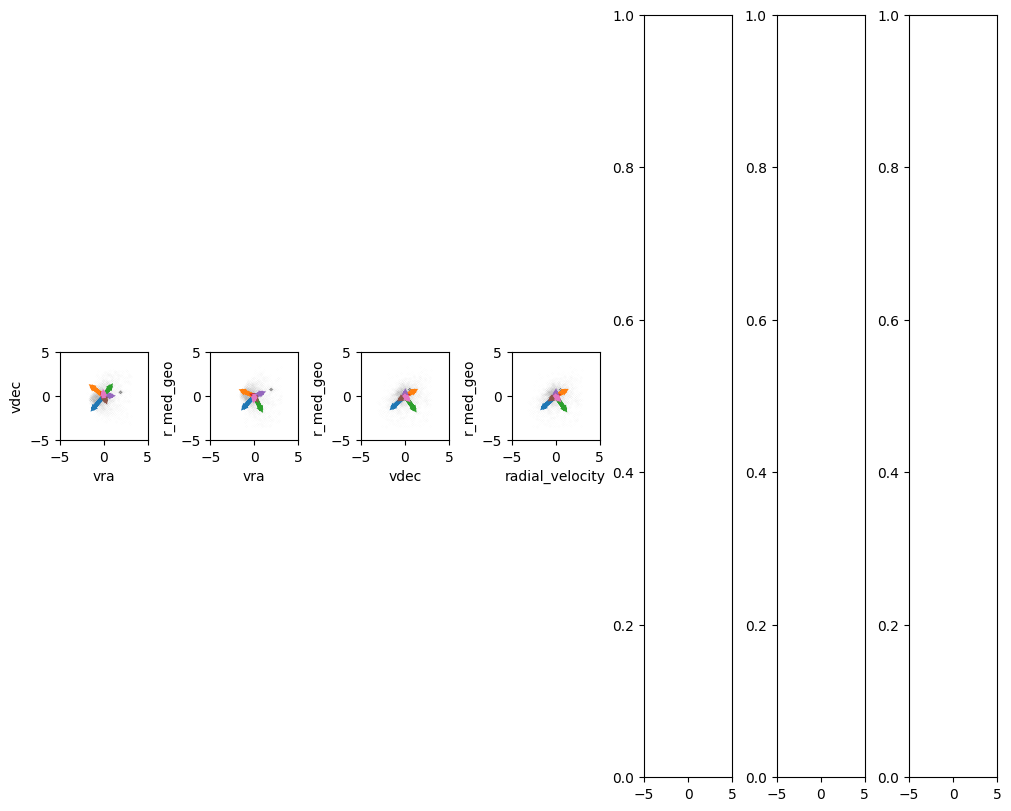

In [30]:
# NOTE: I don't entire understand this code yet unfortunately, so I will have to come back to it

print()
start = "\033[1m" # beginning of bold text
end = "\033[0;0m" # end of bold text
print(f'{start}Trimmed, scaled data + PCs{end}\n')
#display(HTML('<b>Trimmed, scaled data + PCs</b>')) ==> in case you want to use HTML, but will need to import it

fig, axs = plt.subplots(1, len(pca_data_blanco1.columns), figsize=(10,8), sharex=True, constrained_layout=True)

pca_vector_panel(axs[0], pca_data_scaled, pca, 0, 1, 'vra', 'vdec')
pca_vector_panel(axs[1], pca_data_scaled, pca, 0, 2, 'vra','r_med_geo')
pca_vector_panel(axs[2], pca_data_scaled, pca, 1, 2, 'vdec', 'r_med_geo')
pca_vector_panel(axs[3], pca_data_scaled, pca, 1, 2, 'radial_velocity', 'r_med_geo')

plt.show()
plt.close()

## Parameter Exploration

In [31]:
mc_blanco1.columns

Index(['SOURCE_ID', 'ra', 'dec', 'parallax', 'pmra', 'pmdec', 'ruwe',
       'phot_g_mean_flux', 'phot_g_mean_mag', 'phot_g_mean_flux_error',
       'phot_bp_mean_flux', 'phot_bp_mean_mag', 'phot_bp_mean_flux_error',
       'phot_rp_mean_flux', 'phot_rp_mean_mag', 'phot_bp_mean_flux_error_2',
       'bp_rp', 'bp_g', 'g_rp', 'radial_velocity', 'radial_velocity_error',
       'l', 'b', 'teff_gspphot', 'logg_gspphot', 'mh_gspphot',
       'distance_gspphot', 'r_med_geo', 'r_med_photogeo', 'flag',
       'fidelity_v2', 'cluster_flag', 'vra', 'vdec', 'MG', 'distance_raw',
       'vra_raw', 'vdec_raw', 'MG_raw'],
      dtype='object')

### Motion and Light

In [32]:
# You can plot any of the motion/light columns against each other to see their scaling (e.g. pmdec vs. pmra)

columns_motion = ['parallax', 'pmra', 'pmdec', 'r_med_geo', 'vra', 'vdec', 'radial_velocity']
columns_light = ['phot_g_mean_flux', 'phot_g_mean_mag', 'bp_rp', 'teff_gspphot', 'MG']
pca_data_blanco1 = mc_blanco1[columns_motion].copy()
pca_data_blanco1

,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
7,-0.102500,-2.918864,-11.107717,1975.989502,-27.338634,-104.036993,NaN
8,-0.048911,4.022452,-4.073233,2224.760254,42.418220,-42.953718,NaN
10,0.267992,15.697833,-4.801356,3154.718262,234.735422,-71.796433,NaN
11,0.609655,16.548270,-3.036656,1562.191650,122.536438,-22.485799,NaN
12,1.035545,12.686734,-7.109915,1016.069885,61.101485,-34.242569,NaN
...,...,...,...,...,...,...,...
62420,0.270329,1.511676,-0.492036,2154.209717,15.435654,-5.024153,NaN
62421,1.155257,4.304247,-12.439239,1046.568848,21.352237,-61.707783,NaN
62422,3.582866,8.236941,-18.571744,363.674957,14.198998,-32.014331,NaN
62423,0.267630,-0.237556,-4.747927,3149.406738,-3.546282,-70.877947,NaN


In [33]:
sigma = 3
pca_data_blanco1 = pca_data_blanco1
n_components = len(pca_data_blanco1.columns)
apply_pca(sigma, pca_data_blanco1, n_components)

Shape before trimming: (47739, 7)
Shape after trimming: (2909, 7)
We have effectively removed 44830 stars to ease computation. 

Column 0: Mean = 0.00, Variance = 1.00
Column 1: Mean = 0.00, Variance = 1.00
Column 2: Mean = 0.00, Variance = 1.00
Column 3: Mean = 0.00, Variance = 1.00
Column 4: Mean = 0.00, Variance = 1.00
Column 5: Mean = 0.00, Variance = 1.00
Column 6: Mean = 0.00, Variance = 1.00
Marix Mean = 0.00, Matrix Variance = 1.00 

Number of principal components: 7 

Explained variance ratio: [0.33111101 0.2621189  0.18473092 0.14088199 0.04511915 0.02221327
 0.01382477] 

Original dataset:


,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
7,-0.102500,-2.918864,-11.107717,1975.989502,-27.338634,-104.036993,NaN
8,-0.048911,4.022452,-4.073233,2224.760254,42.418220,-42.953718,NaN
10,0.267992,15.697833,-4.801356,3154.718262,234.735422,-71.796433,NaN
11,0.609655,16.548270,-3.036656,1562.191650,122.536438,-22.485799,NaN
12,1.035545,12.686734,-7.109915,1016.069885,61.101485,-34.242569,NaN
...,...,...,...,...,...,...,...
62420,0.270329,1.511676,-0.492036,2154.209717,15.435654,-5.024153,NaN
62421,1.155257,4.304247,-12.439239,1046.568848,21.352237,-61.707783,NaN
62422,3.582866,8.236941,-18.571744,363.674957,14.198998,-32.014331,NaN
62423,0.267630,-0.237556,-4.747927,3149.406738,-3.546282,-70.877947,NaN



Trimmed and scaled dataset:


,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
0,-0.541984,0.998058,-1.784492,-0.024193,1.359275,-1.941021,1.725616
1,-0.121554,0.312653,0.714492,-0.323419,0.254117,0.720505,-0.214348
2,-0.875233,-0.465551,0.735851,0.449527,-0.344821,0.839973,-1.764613
3,0.058796,0.126321,0.098514,-0.421056,0.011464,0.258768,-0.321866
4,-0.493282,-0.066576,-0.756980,-0.060810,0.048134,-0.789777,-0.820358
...,...,...,...,...,...,...,...
2904,2.318141,-2.425849,0.709339,-0.878551,-1.275233,0.655894,0.227060
2905,1.923334,0.514202,0.736609,-0.838765,-0.134457,0.670215,0.021512
2906,0.048447,-1.009973,0.552828,-0.415770,-0.925427,0.591014,-0.015907
2907,-1.066806,-0.007857,0.801440,0.855821,0.667270,1.014806,0.711211



PC dataframe:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,1.212078,0.965261,2.588054,1.887763,-0.519262,-0.182360,-0.319977
1,-0.967965,0.271119,-0.489894,-0.160585,-0.270617,-0.070708,-0.052859
2,-0.020402,0.565577,-1.455526,-1.742819,-0.339783,0.112592,0.245441
3,-0.430642,-0.145750,0.007919,-0.327628,-0.244102,-0.043650,-0.038828
4,0.878068,0.211041,0.667829,-0.813777,-0.416551,-0.089699,-0.134899
...,...,...,...,...,...,...,...
2904,-0.415270,-3.078321,-1.263886,-0.134783,1.230433,1.023614,-0.903145
2905,-1.873177,-1.106752,0.231566,-0.054193,0.930108,-0.072767,-0.129694
2906,-0.026314,-1.070976,-1.219112,-0.175526,-0.136770,0.047535,-0.145437
2907,-0.306393,1.304823,-1.259097,0.874017,-0.325116,0.401986,0.284271



PCA transformation coefficients matrix:


,parallax,pmra,pmdec,r_med_geo,vra,vdec,radial_velocity
PC1,-0.368393,-0.436308,-0.401558,0.380220,-0.271725,-0.541388,0.034191
PC2,-0.461942,0.366032,0.199153,0.504184,0.581077,-0.073828,-0.125164
PC3,0.313004,0.436059,-0.613716,-0.223543,0.318874,-0.427777,-0.024256
PC4,-0.034281,0.046189,0.016803,0.041296,0.116289,0.006832,0.990522
PC5,0.707968,0.018654,0.281687,0.592869,-0.089528,-0.244000,0.006330
PC6,0.221079,-0.555292,-0.367407,0.185781,0.537348,0.428221,-0.034007
PC7,-0.040665,0.417945,-0.455878,0.404408,-0.420182,0.524880,0.015687


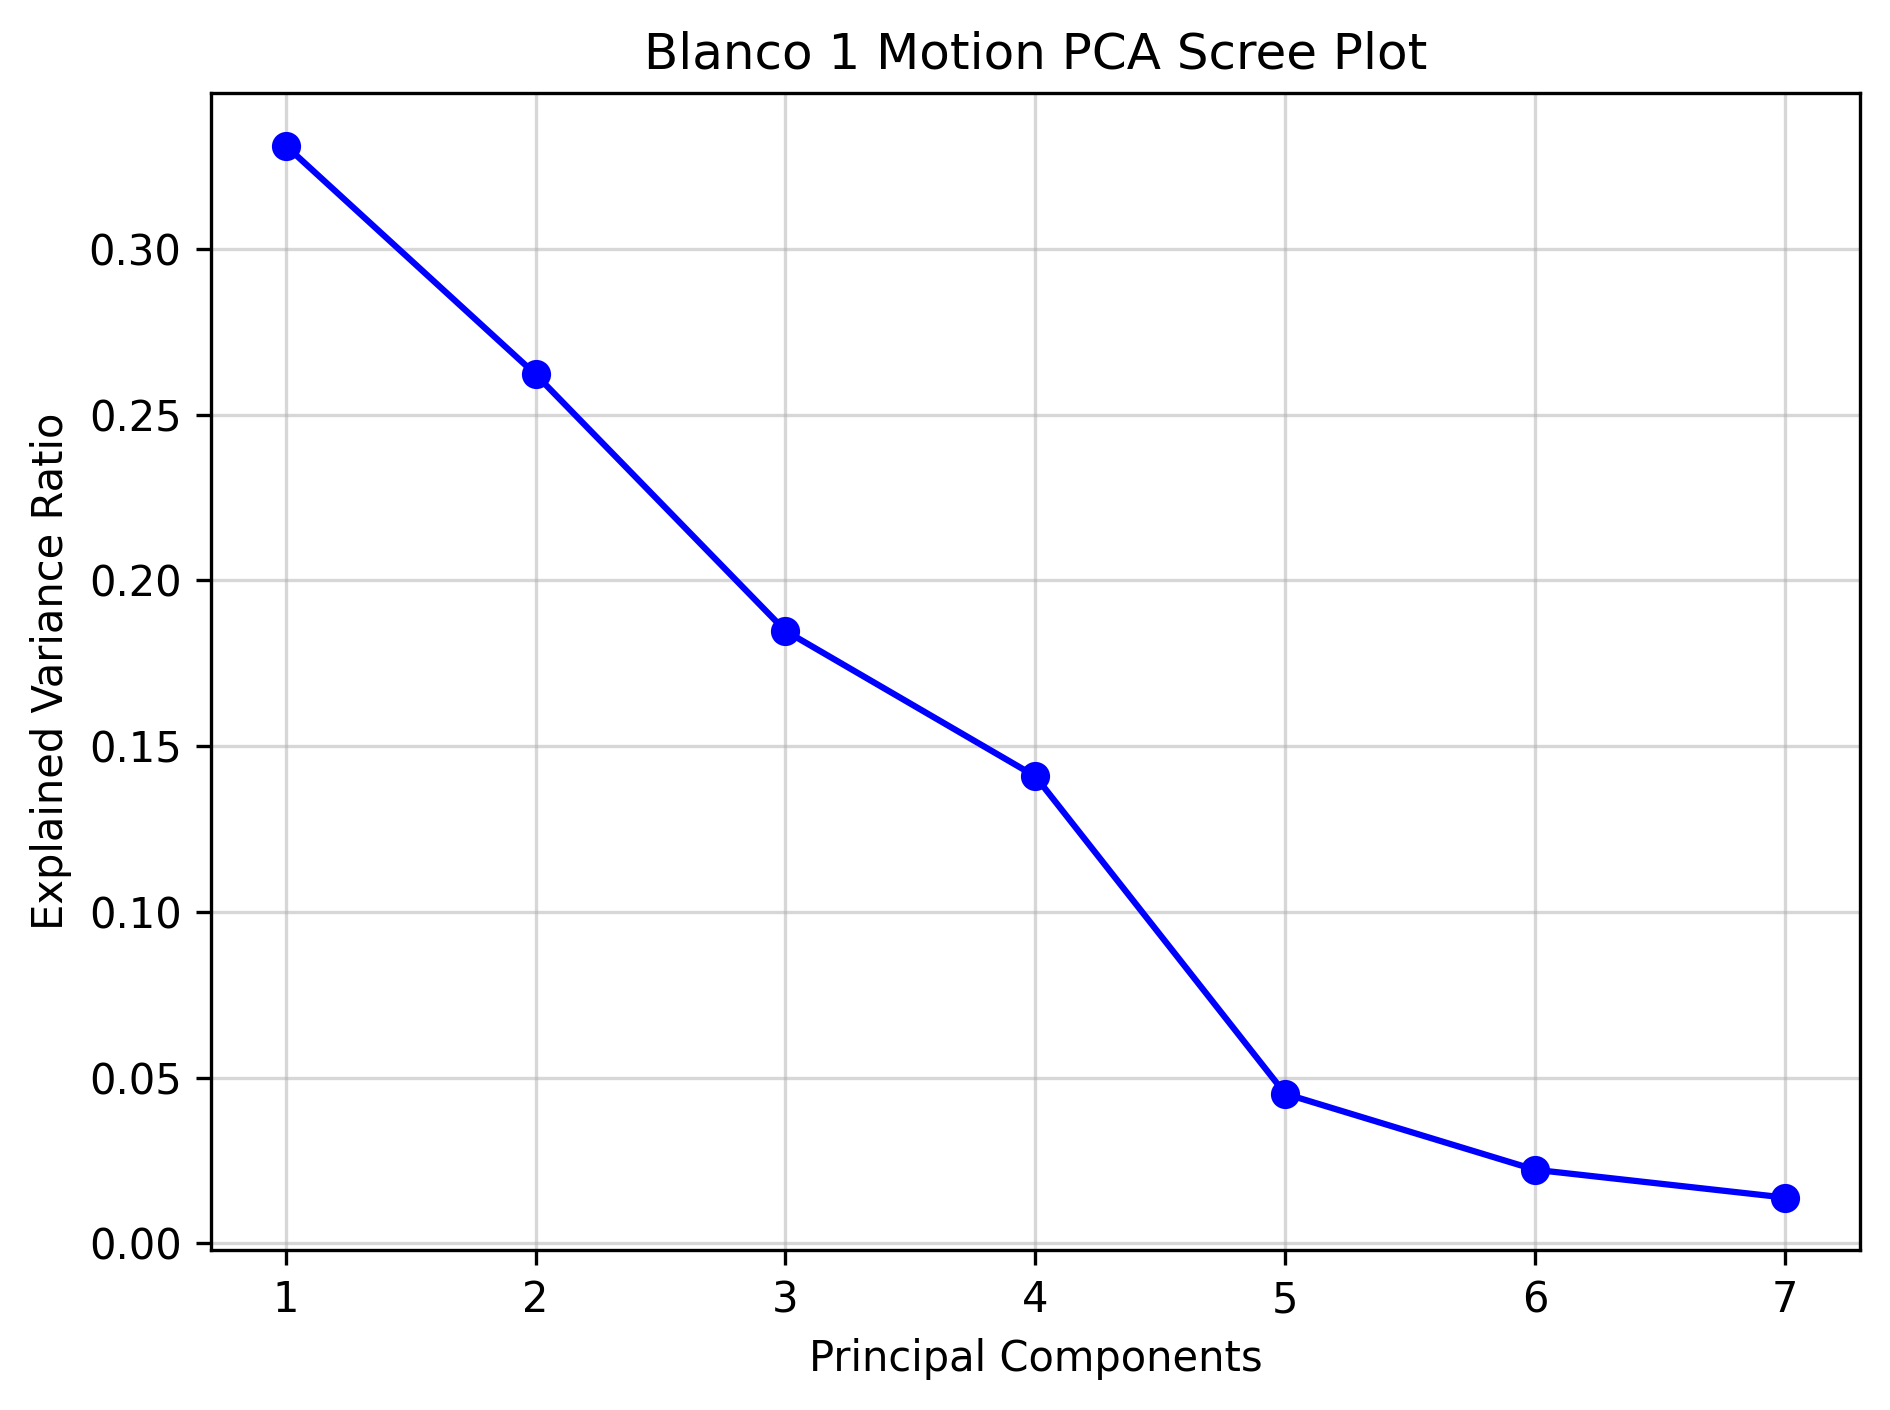

In [34]:
# Scree Plot - recall that the 'elbow' in the curve is the number of components we need for accurate PCA results

plt.figure(dpi=300)

plt.plot(range(1, n_components + 1), ratio, 'bo-')
plt.xticks(range(1, n_components + 1))
plt.grid(alpha=0.5)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Blanco 1 Motion PCA Scree Plot' if (pca_data_blanco1.columns.tolist() == columns_motion) else 'Blanco 1 Light PCA Scree Plot')
plt.tight_layout()

#plt.savefig('Blanco 1 Light PCA.png', dpi=1200)
plt.show()
plt.close()

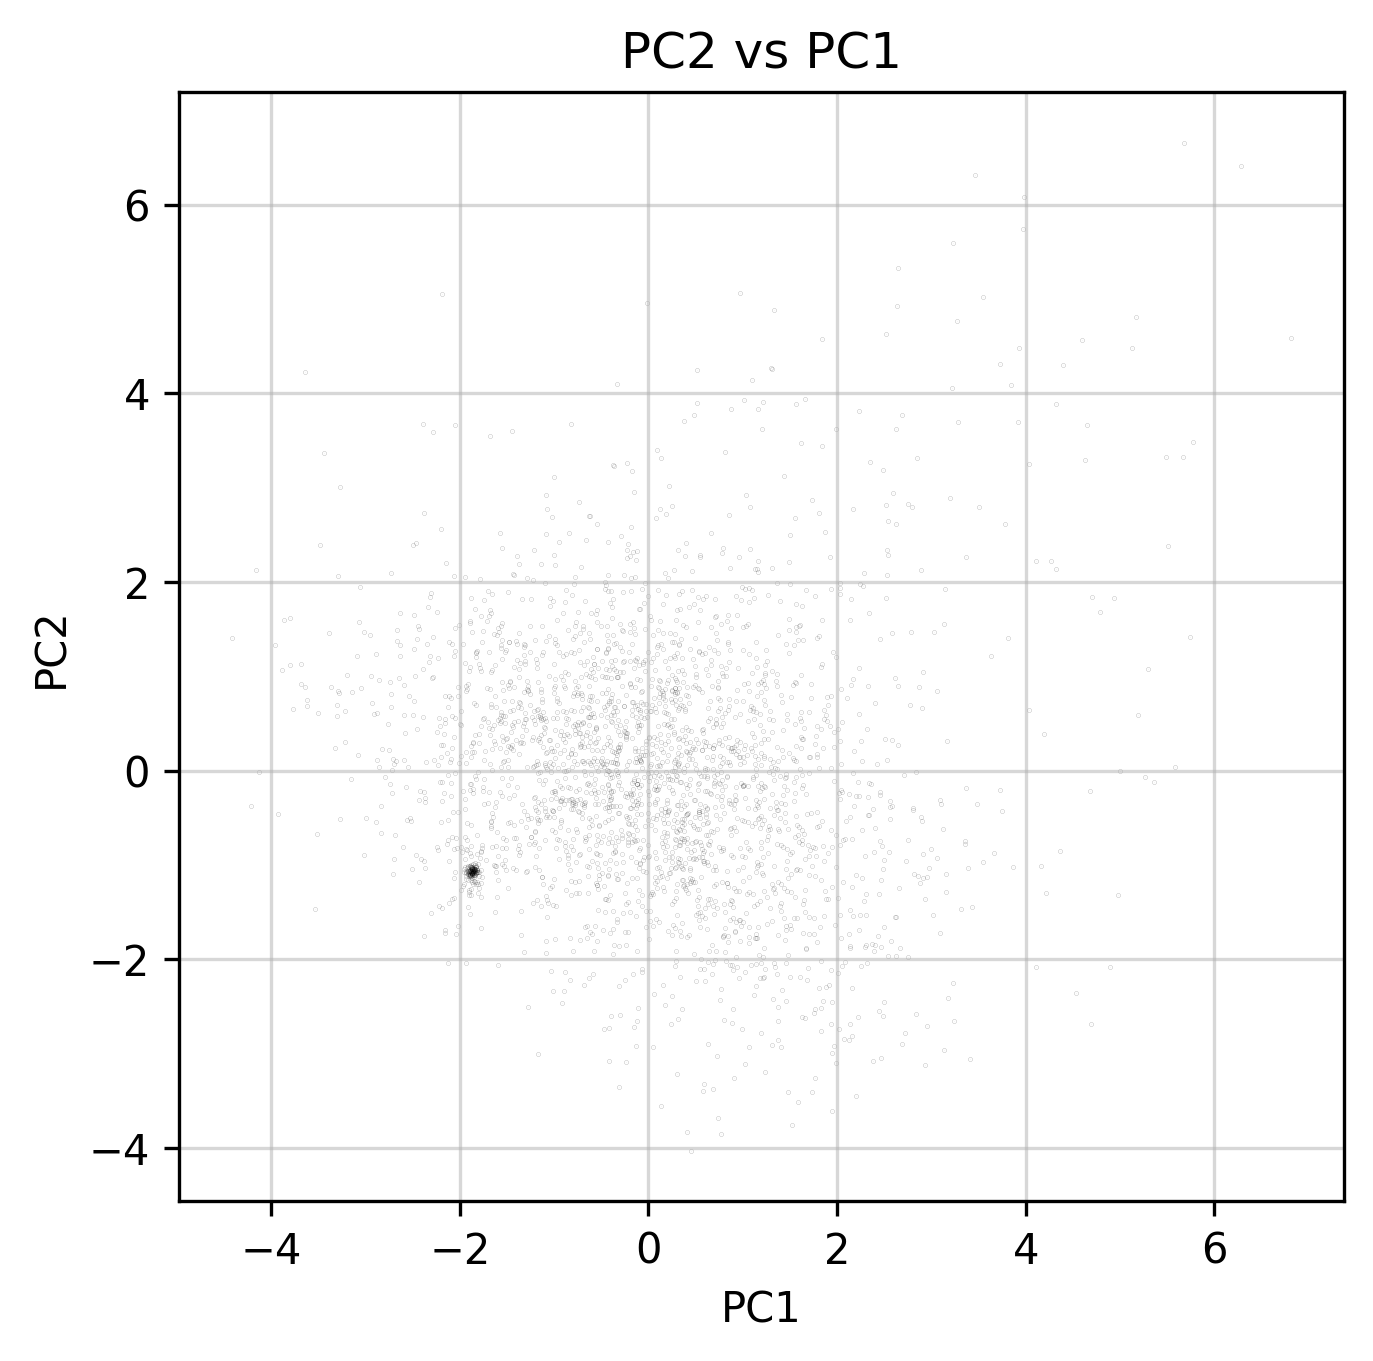

In [35]:
# PCs

pcx = pc_df.PC1
pcy = pc_df.PC2

plt.figure(dpi=300)

plt.scatter(pcx, pcy, s=0.01, alpha=0.3, c='0')
plt.title(f'PC{pcy.name[-1]} vs PC{pcx.name[-1]}')
plt.xlabel(f'PC{pcx.name[-1]}')
plt.ylabel(f'PC{pcy.name[-1]}')
#plt.xlim(-0.5, 0.5)
#plt.ylim(-0.5, 0.5)
plt.gca().set_aspect(1)
plt.grid(alpha=0.5)

plt.show()
plt.close()

### Velocities

In [36]:
columns_velocity = ['vra', 'vdec', 'radial_velocity']
pca_data_blanco1 = mc_blanco1[columns_velocity].copy()
pca_data_blanco1

,vra,vdec,radial_velocity
7,-27.338634,-104.036993,NaN
8,42.418220,-42.953718,NaN
10,234.735422,-71.796433,NaN
11,122.536438,-22.485799,NaN
12,61.101485,-34.242569,NaN
...,...,...,...
62420,15.435654,-5.024153,NaN
62421,21.352237,-61.707783,NaN
62422,14.198998,-32.014331,NaN
62423,-3.546282,-70.877947,NaN


In [37]:
sigma = 3
pca_data_blanco1 = pca_data_blanco1
n_components = len(pca_data_blanco1.columns)
apply_pca(sigma, pca_data_blanco1, n_components)

Shape before trimming: (47739, 3)
Shape after trimming: (3320, 3)
We have effectively removed 44419 stars to ease computation. 

Column 0: Mean = 0.00, Variance = 1.00
Column 1: Mean = 0.00, Variance = 1.00
Column 2: Mean = 0.00, Variance = 1.00
Marix Mean = 0.00, Matrix Variance = 1.00 

Number of principal components: 3 

Explained variance ratio: [0.38508787 0.33367681 0.28123531] 

Original dataset:


,vra,vdec,radial_velocity
7,-27.338634,-104.036993,NaN
8,42.418220,-42.953718,NaN
10,234.735422,-71.796433,NaN
11,122.536438,-22.485799,NaN
12,61.101485,-34.242569,NaN
...,...,...,...
62420,15.435654,-5.024153,NaN
62421,21.352237,-61.707783,NaN
62422,14.198998,-32.014331,NaN
62423,-3.546282,-70.877947,NaN



Trimmed and scaled dataset:


,vra,vdec,radial_velocity
0,1.303483,-1.763472,1.725705
1,0.246274,0.708591,-0.216381
2,-0.326678,0.819554,-1.768342
3,0.014149,0.279723,-0.324016
4,0.049228,-0.694180,-0.823054
...,...,...,...
3315,-1.216721,0.648579,0.225510
3316,-0.125440,0.661881,0.019737
3317,-0.882092,0.588318,-0.017723
3318,0.641502,0.981942,0.710191



PC dataframe:


,PC1,PC2,PC3
0,0.723817,-0.783619,2.578563
1,-0.691836,-0.110924,-0.344431
2,-0.826566,1.236435,-1.301321
3,-0.286495,0.170777,-0.268678
4,0.158723,1.042887,0.221180
...,...,...,...
3315,0.516382,-0.490829,-1.201813
3316,-0.327303,-0.305406,-0.503797
3317,0.244184,-0.243754,-1.002734
3318,-0.865629,-1.062294,0.048190



PCA transformation coefficients matrix:


,vra,vdec,radial_velocity
PC1,-0.708265,-0.637761,0.302691
PC2,0.005283,-0.433549,-0.901114
PC3,0.705927,-0.636629,0.310437


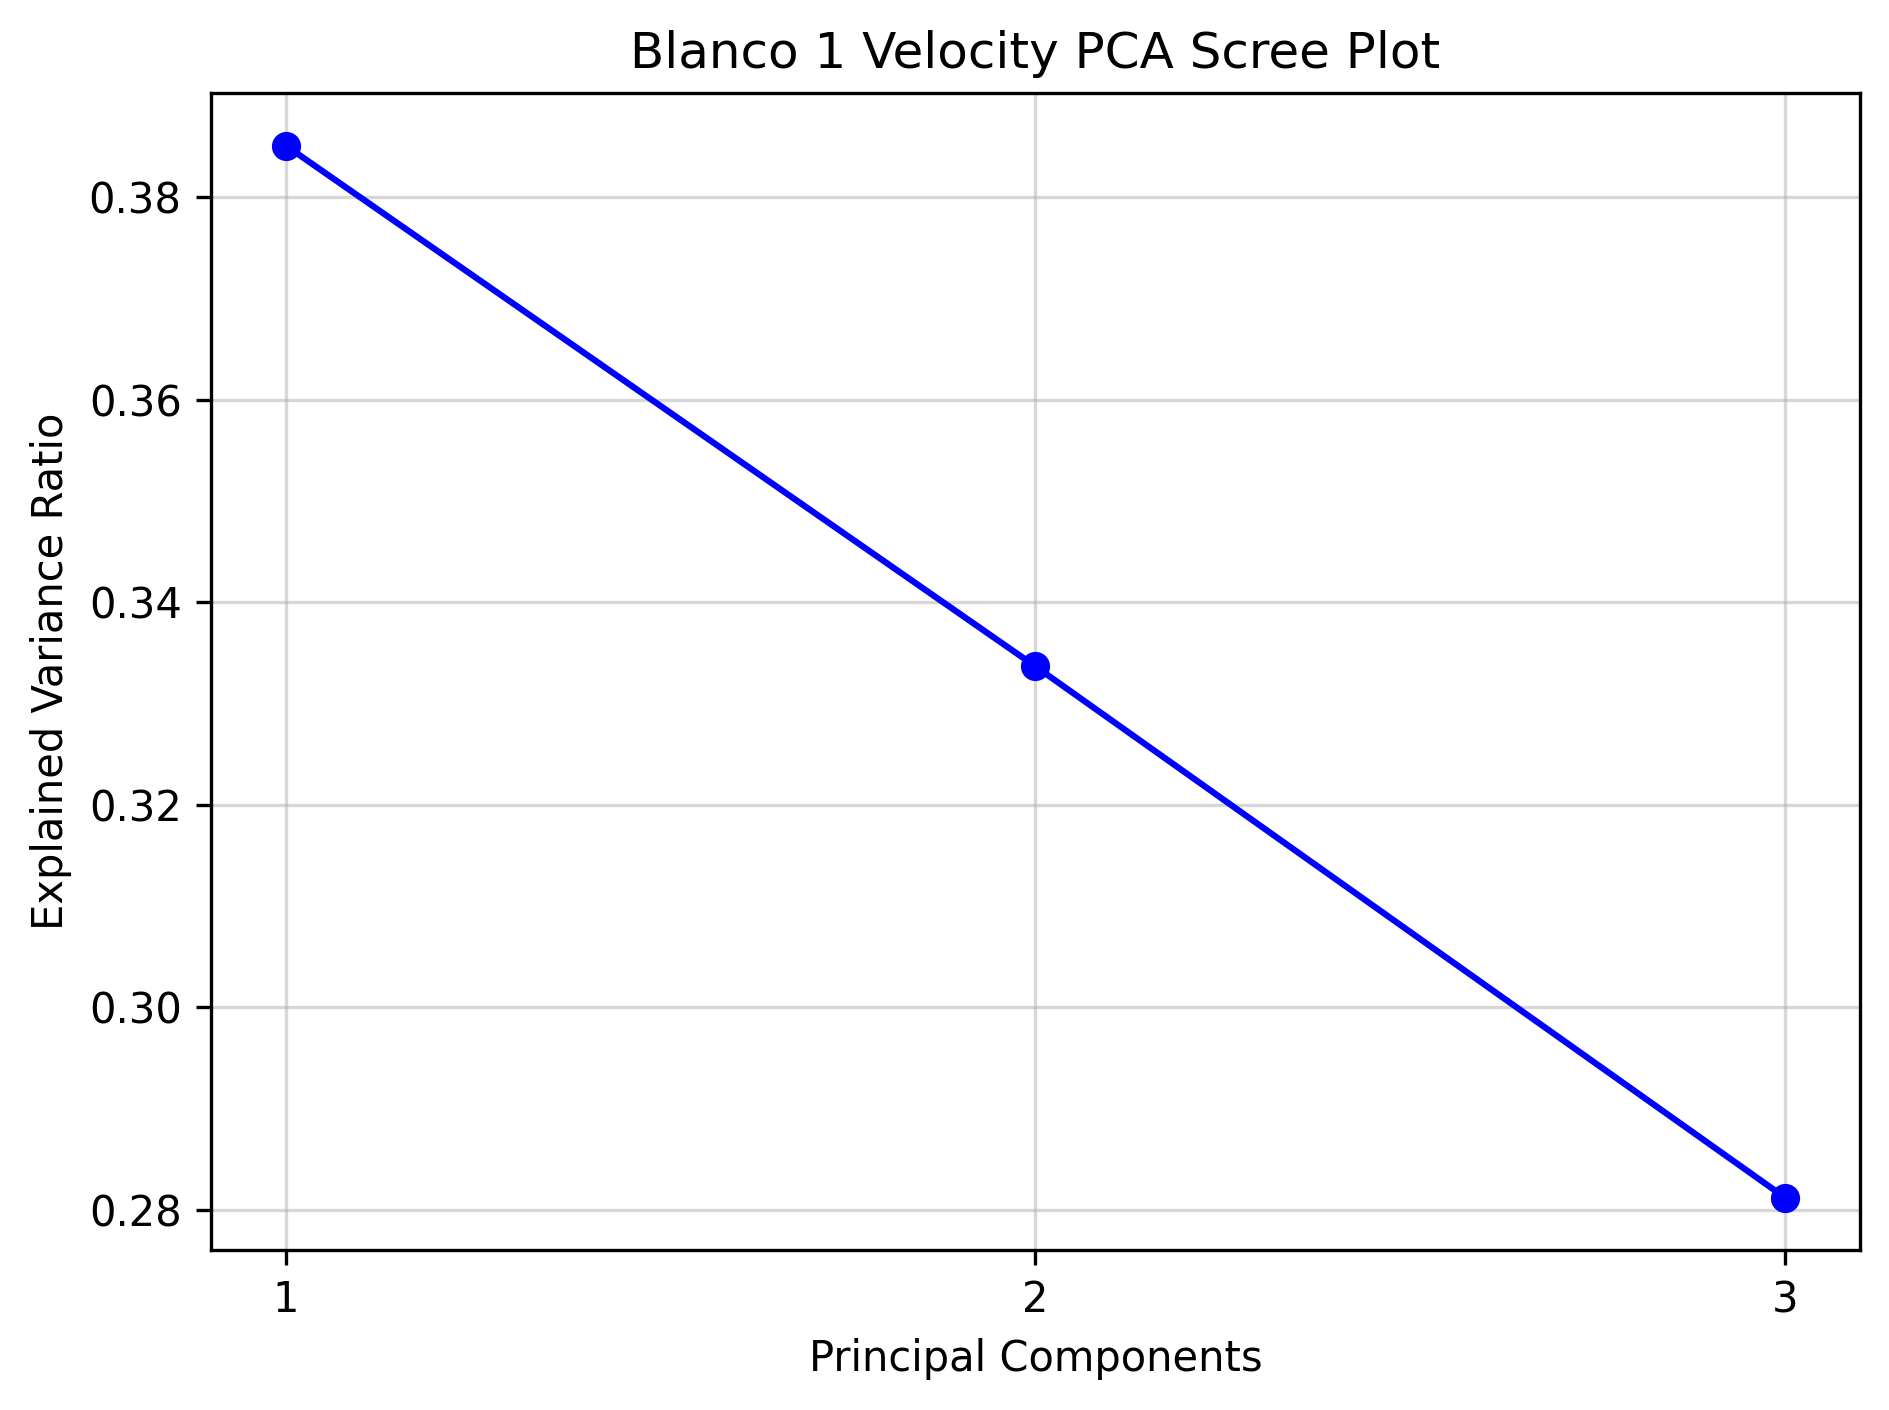

In [38]:
# Scree Plot - recall that the 'elbow' in the curve is the number of components we need for accurate PCA results

plt.figure(dpi=300)

plt.plot(range(1, n_components + 1), ratio, 'bo-')
plt.xticks(range(1, n_components + 1))
plt.grid(alpha=0.5)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Blanco 1 Velocity PCA Scree Plot')
plt.tight_layout()

#plt.savefig('Blanco 1 Light PCA.png', dpi=1200)
plt.show()
plt.close()

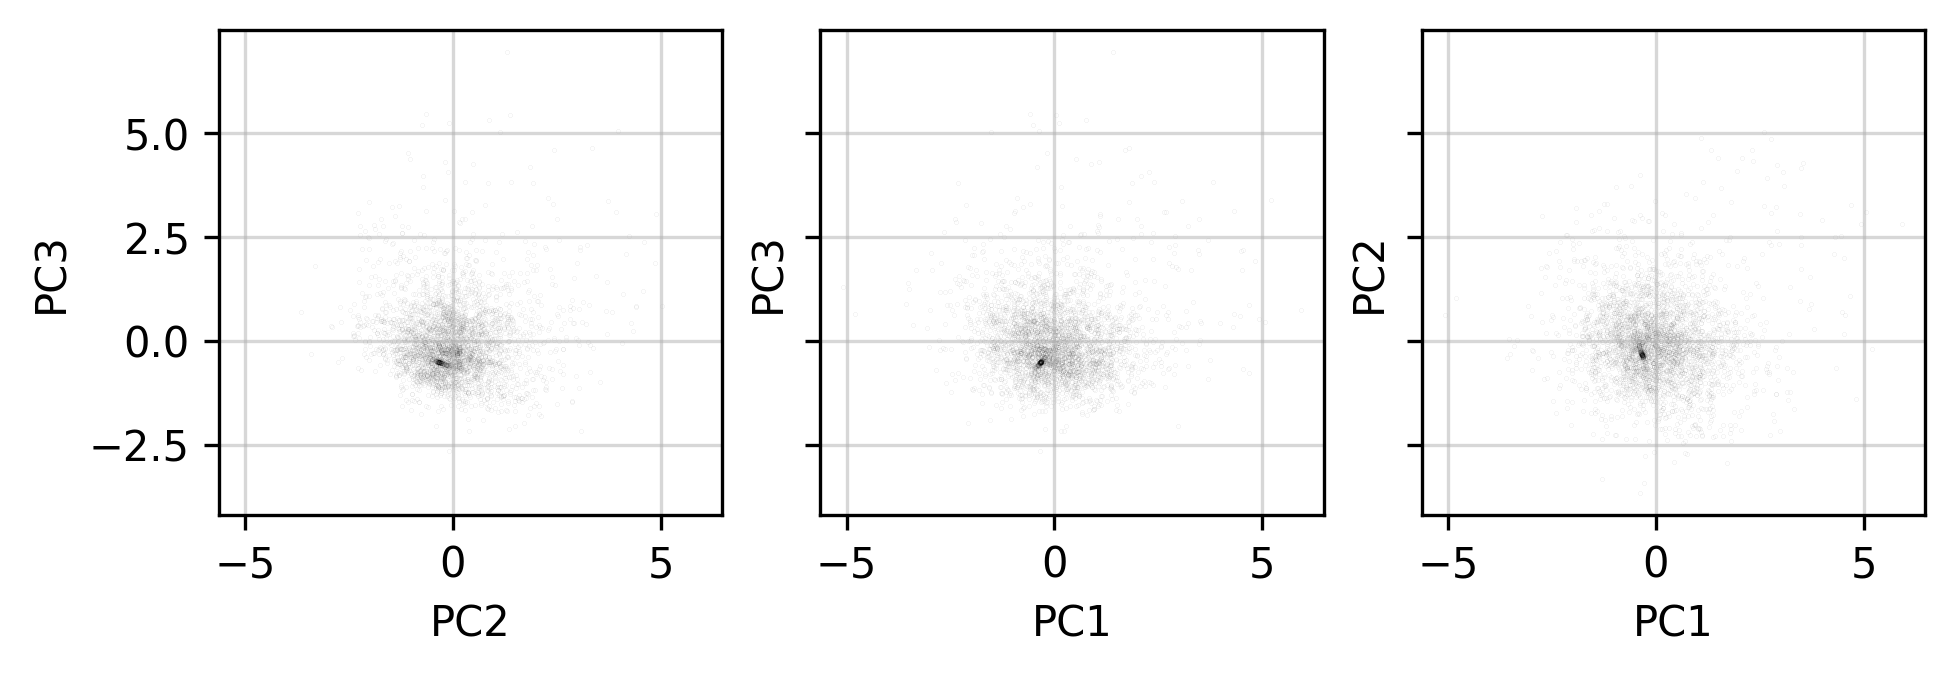

In [39]:
# PCs

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, constrained_layout=True, dpi=300)

ax = axs[0]
ax.scatter(pc_df.PC2, pc_df.PC3, s=0.001, alpha=0.3, c='0')
ax.set_xlabel('PC2')
ax.set_ylabel('PC3')
#plt.xlim(-0.5, 0.5)
#plt.ylim(-0.5, 0.5)
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[1]
ax.scatter(pc_df.PC1, pc_df.PC3, s=0.001, alpha=0.3, c='0')
ax.set_xlabel('PC1')
ax.set_ylabel('PC3')
#plt.xlim(-0.5, 0.5)
#plt.ylim(-0.5, 0.5)
ax.set_aspect(1)
ax.grid(alpha=0.5)

ax = axs[2]
ax.scatter(pc_df.PC1, pc_df.PC2, s=0.001, alpha=0.3, c='0')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
#plt.xlim(-0.5, 0.5)
#plt.ylim(-0.5, 0.5)
ax.set_aspect(1)
ax.grid(alpha=0.5)

plt.show()
plt.close()